# Optimise Models 
Train and test in subgroups


## 1. Import Libraries

In [9]:
import os
import warnings
warnings.simplefilter("ignore")
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_predict
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from config_models import (
    TRAIN_DATA_PATH,
    TEST_DATA_PATH,
    TRAIN_SUBGROUP_DATA_PATH,
    TEST_SUBGROUP_DATA_PATH,
    SUBGROUP_COLS,
    OUTPUT_DIR,
)

from models_helpers import (
    get_model_specs,
    tune_model,
    evaluate_fitted_model,
)


RANDOM_STATE = 42
N_SPLITS = 5


OPTIMISATION_METHOD = "subgroup_specific_models"

OPTIMISATION_DIR = os.path.join(
    OUTPUT_DIR,
    "optimisation",
    OPTIMISATION_METHOD
    
)

os.makedirs(OPTIMISATION_DIR, exist_ok=True)

In [2]:
%run ../sdc_helpers.py

IS_DUMMY_DATA = os.getenv("OPENSAFELY_BACKEND") is None

MIN_TRAIN_PER_CLASS = max(
    N_SPLITS,
    DISCLOSURE_THRESHOLD + 1
)

MIN_TEST_PER_CLASS = DISCLOSURE_THRESHOLD + 1

## 2. Load Data

In [3]:
train_data = pd.read_csv(TRAIN_DATA_PATH)
test_data = pd.read_csv(TEST_DATA_PATH)

train_subgroup_data = pd.read_csv(TRAIN_SUBGROUP_DATA_PATH)
test_subgroup_data = pd.read_csv(TEST_SUBGROUP_DATA_PATH)

# 3. Prepare Predictors and Outcome

In [4]:
age_band_cols = [
    col for col in train_data.columns
    if col.startswith("age_band_")
]

drop_cols = ["patient_id", "hf_outcome"] + age_band_cols

X_train = train_data.drop(columns=drop_cols)
y_train = train_data["hf_outcome"]

X_test = test_data.drop(columns=drop_cols)
y_test = test_data["hf_outcome"]



# 4. Subgroups and Models

In [5]:
subgroup_vars = [
    col for col in SUBGROUP_COLS
    if col not in ["patient_id", "hf_outcome"]
]

cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

# 5. Train and Evaluate

In [6]:
performance_rows = []
skipped_rows = []

for subgroup_var in subgroup_vars:

    levels = pd.concat([
        train_subgroup_data[subgroup_var],
        test_subgroup_data[subgroup_var],
    ]).unique()

    for level_number, subgroup_level in enumerate(levels):

        # Relabel empty level to "Missing"
        if pd.isna(subgroup_level):
            train_mask = train_subgroup_data[subgroup_var].isna()
            test_mask = test_subgroup_data[subgroup_var].isna()
            level_label = "Missing"
        else:
            train_mask = train_subgroup_data[subgroup_var] == subgroup_level
            test_mask = test_subgroup_data[subgroup_var] == subgroup_level
            level_label = str(subgroup_level)

        X_train_sub = X_train.loc[train_mask]
        y_train_sub = y_train.loc[train_mask]

        X_test_sub = X_test.loc[test_mask]
        y_test_sub = y_test.loc[test_mask]

        group_info = {
            "subgroup_variable": subgroup_var,
            "subgroup_level": level_label,
            "level_number": level_number,
            "n_train": len(y_train_sub),
            "train_events": int((y_train_sub == 1).sum()),
            "train_nonevents": int((y_train_sub == 0).sum()),
            "n_test": len(y_test_sub),
            "test_events": int((y_test_sub == 1).sum()),
            "test_nonevents": int((y_test_sub == 0).sum()),
        }

        if min(
            group_info["train_events"],
            group_info["train_nonevents"]
        ) < MIN_TRAIN_PER_CLASS:

            skipped_rows.append({
                **group_info,
                "reason": "Too few training cases or non-cases",
            })

            continue

        if min(
            group_info["test_events"],
            group_info["test_nonevents"]
        ) < MIN_TEST_PER_CLASS:

            skipped_rows.append({
                **group_info,
                "reason": "Too few test cases or non-cases",
            })

            continue

        group_dir = os.path.join(
            OPTIMISATION_DIR,
            subgroup_var,
            f"level_{level_number}"
        )

        os.makedirs(group_dir, exist_ok=True)

        model_specs = get_model_specs(
            y_train=y_train_sub,
            random_state=RANDOM_STATE,
        )

        for model_name, spec in model_specs.items():

            print(
                f"Training {model_name}: "
                f"{subgroup_var} = {level_label}"
            )

            search = tune_model(
                model_name=model_name,
                model=spec["model"],
                params=spec["params"],
                search_type=spec["search_type"],
                X_train=X_train_sub,
                y_train=y_train_sub,
                cv=cv,
                scoring="roc_auc",
                n_iter=spec["n_iter"],
                random_state=RANDOM_STATE,
            )

            pd.DataFrame(
                search.cv_results_
            ).to_csv(
                os.path.join(
                    group_dir,
                    f"cv_results_{model_name}.csv"
                ),
                index=False,
            )

            test_pred, test_prob, performance, _ = evaluate_fitted_model(
                model=search.best_estimator_,
                X=X_train_sub,
                y=y_train_sub,
                X_val=X_test_sub,
                y_val=y_test_sub,
                threshold=None,
            )

            performance.update(group_info)

            performance["model"] = model_name
            performance["best_cv_score"] = search.best_score_
            performance["best_params"] = str(search.best_params_)
            performance["threshold_method"] = "event_rate_train"

            performance_rows.append(performance)

            prediction_df = pd.DataFrame({
                "patient_id": test_data.loc[
                    test_mask,
                    "patient_id"
                ].to_numpy(),
                "hf_outcome": y_test_sub.to_numpy(),
                "probability": test_prob,
                "prediction": test_pred,
            })

            prediction_df.to_csv(
                os.path.join(
                    group_dir,
                    f"test_predictions_{model_name}.csv.gz"
                ),
                index=False,
                compression="gzip",
            )

            del search

Training lr: age_band = 50-54
Fitting 5 folds for each of 6 candidates, totalling 30 fits
lr: best CV roc_auc = 0.5427
lr: best params = {'model__C': 10, 'model__l1_ratio': 0.5, 'model__penalty': 'elasticnet', 'model__solver': 'saga'}
Training rf: age_band = 50-54
Fitting 5 folds for each of 25 candidates, totalling 125 fits
rf: best CV roc_auc = 0.5284
rf: best params = {'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 30, 'criterion': 'entropy', 'class_weight': 'balanced'}
Training hgb: age_band = 50-54
Fitting 5 folds for each of 20 candidates, totalling 100 fits
hgb: best CV roc_auc = 0.5299
hgb: best params = {'max_iter': 200, 'max_depth': 2, 'learning_rate': 0.1}
Training xgb: age_band = 50-54
Fitting 5 folds for each of 25 candidates, totalling 125 fits
xgb: best CV roc_auc = 0.5106
xgb: best params = {'subsample': 0.7, 'scale_pos_weight': 0.24180327868852458, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'gamma

/Users/cu20932/Documents/Work/reducehf/fresh_env/lib/python3.9/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['rural_urban']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/cu20932/Documents/Work/reducehf/fresh_env/lib/python3.9/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['rural_urban']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/cu20932/Documents/Work/reducehf/fresh_env/lib/python3.9/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['rural_urban']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/cu20932/Documents/Work/reducehf/fresh_env/lib/python3.9/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed va

lr: best CV roc_auc = 0.5572
lr: best params = {'model__C': 0.1, 'model__l1_ratio': 0.5, 'model__penalty': 'elasticnet', 'model__solver': 'saga'}
Training rf: rural_urban = Missing
Fitting 5 folds for each of 25 candidates, totalling 125 fits
rf: best CV roc_auc = 0.5723
rf: best params = {'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 10, 'criterion': 'log_loss', 'class_weight': 'balanced'}
Training hgb: rural_urban = Missing
Fitting 5 folds for each of 20 candidates, totalling 100 fits
hgb: best CV roc_auc = 0.5619
hgb: best params = {'max_iter': 200, 'max_depth': 2, 'learning_rate': 0.1}
Training xgb: rural_urban = Missing
Fitting 5 folds for each of 25 candidates, totalling 125 fits
xgb: best CV roc_auc = 0.5736
xgb: best params = {'subsample': 0.7, 'scale_pos_weight': 0.27055369127516776, 'n_estimators': 400, 'max_depth': 2, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.7}
Training lr: rural_urban = 4.0
Fitting 

# 6. Save

In [7]:
performance_df = pd.DataFrame(performance_rows)


skipped_df = pd.DataFrame(skipped_rows, columns=[
    "subgroup_variable",
    "subgroup_level",
    "level_number",
    "n_train",
    "train_events",
    "train_nonevents",
    "n_test",
    "test_events",
    "test_nonevents",
    "reason",
])

performance_count_cols = [
    "n_train",
    "train_events",
    "train_nonevents",
    "n_test",
    "test_events",
    "test_nonevents",
    "true_positives",
    "false_positives",
    "true_negatives",
    "false_negatives",
]

skipped_count_cols = [
    "n_train",
    "train_events",
    "train_nonevents",
    "n_test",
    "test_events",
    "test_nonevents",
]

performance_output_df = performance_df.copy()
skipped_output_df = skipped_df.copy()

if not IS_DUMMY_DATA:

    performance_output_df[performance_count_cols] = (
        performance_output_df[performance_count_cols]
        .apply(
            apply_disclosure_control,
            threshold=DISCLOSURE_THRESHOLD
        )
    )

    skipped_output_df[skipped_count_cols] = (
        skipped_output_df[skipped_count_cols]
        .apply(
            apply_disclosure_control,
            threshold=DISCLOSURE_THRESHOLD
        )
    )

performance_output_df.to_csv(
    os.path.join(OPTIMISATION_DIR, "test_performance.csv"),
    index=False,
)

skipped_output_df.to_csv(
    os.path.join(OPTIMISATION_DIR, "skipped_subgroups.csv"),
    index=False,
)

print("Subgroup model results:", len(performance_df))
print("Skipped subgroups:", len(skipped_df))
print("Saved results to:", OPTIMISATION_DIR)

Subgroup model results: 216
Skipped subgroups: 15
Saved results to: /Users/cu20932/Documents/Work/reducehf/output/models/optimisation/subgroup_specific_models/internal


## 7. Confusion Matrix

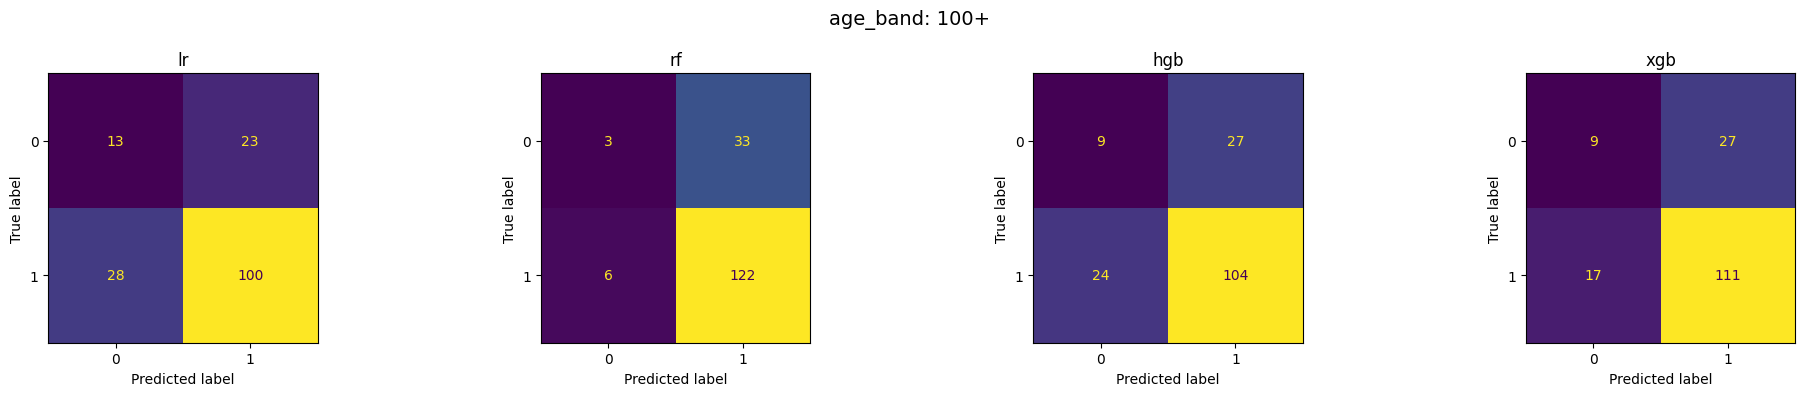

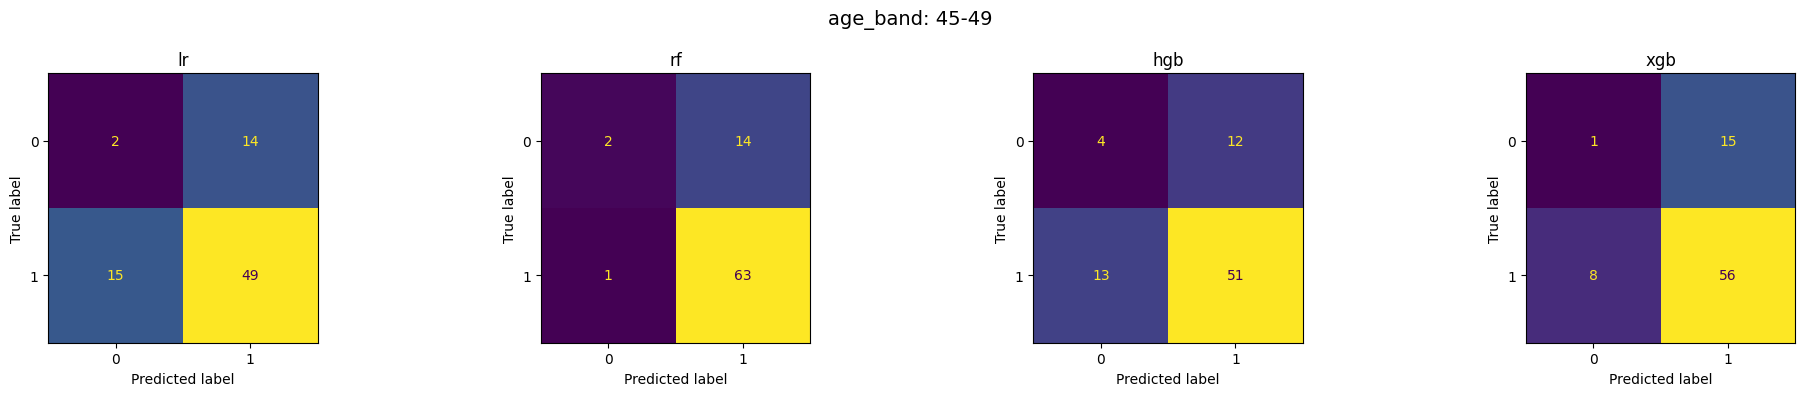

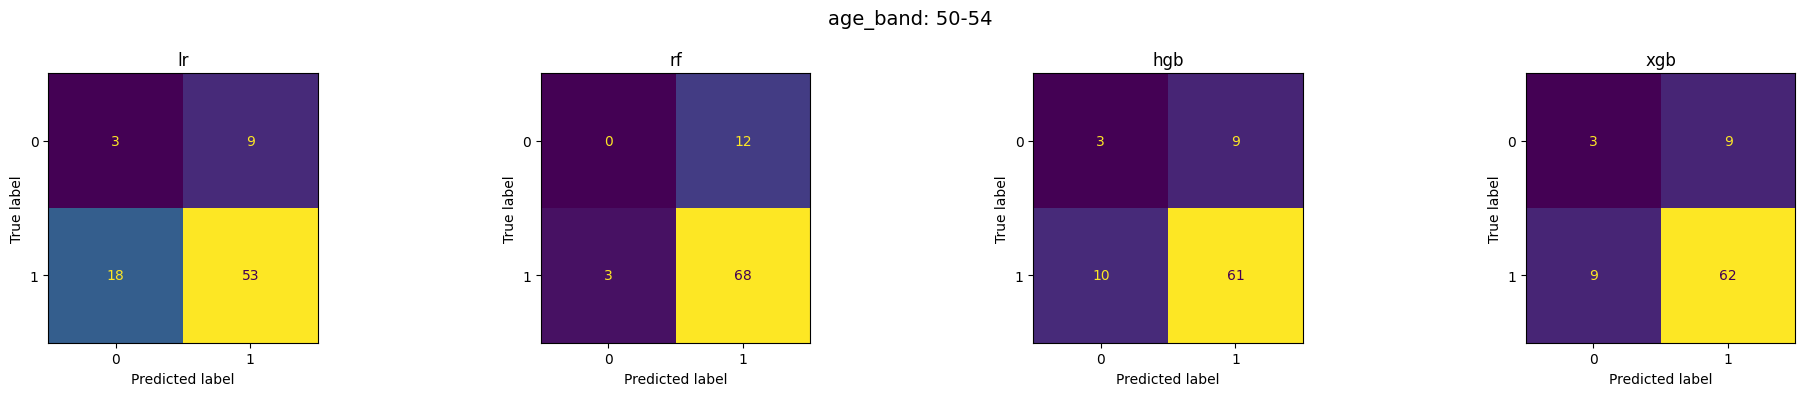

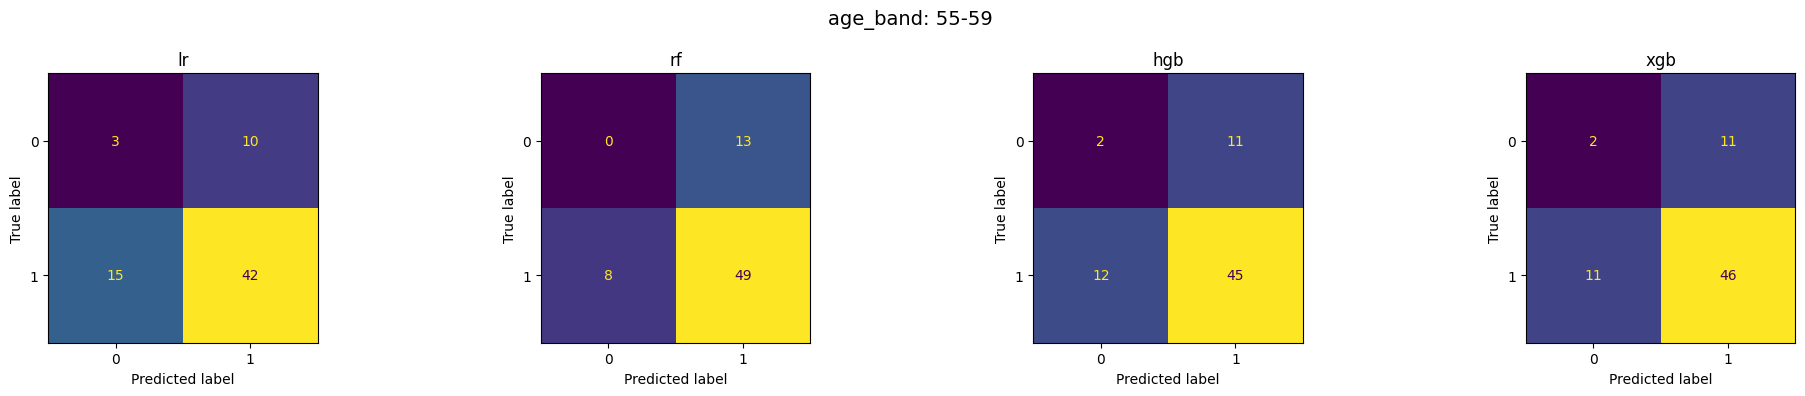

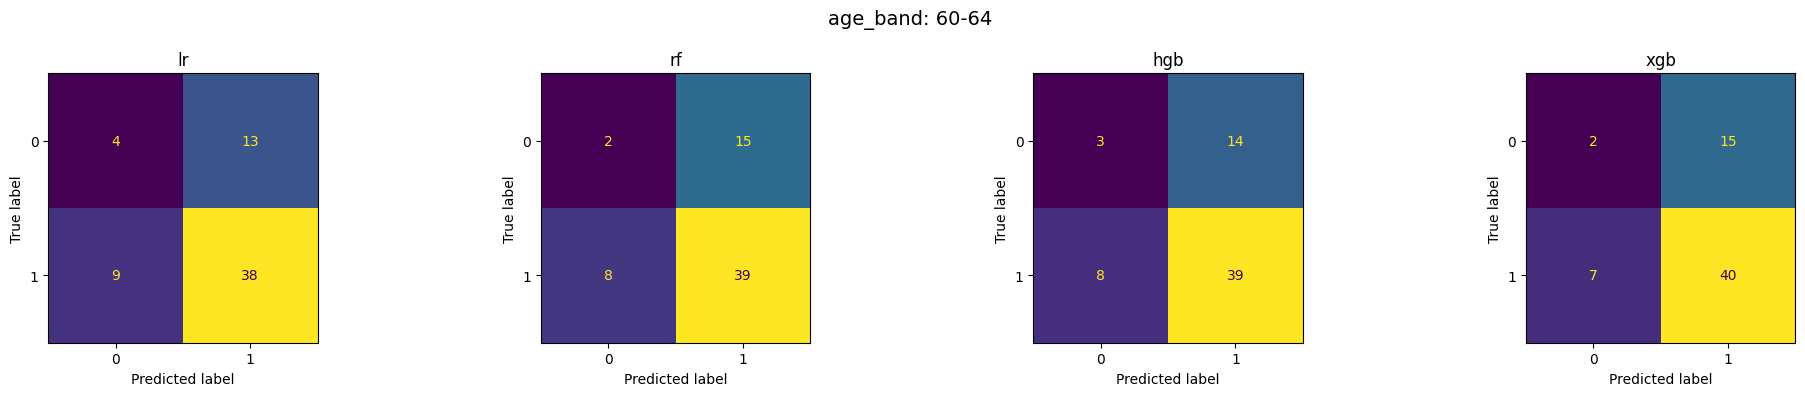

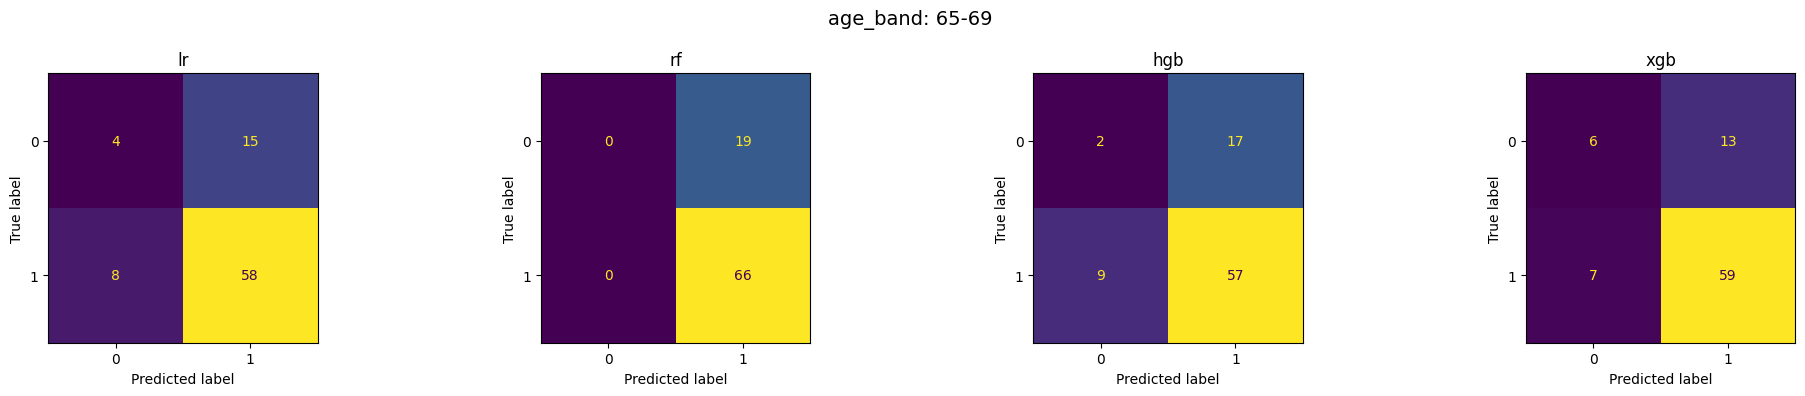

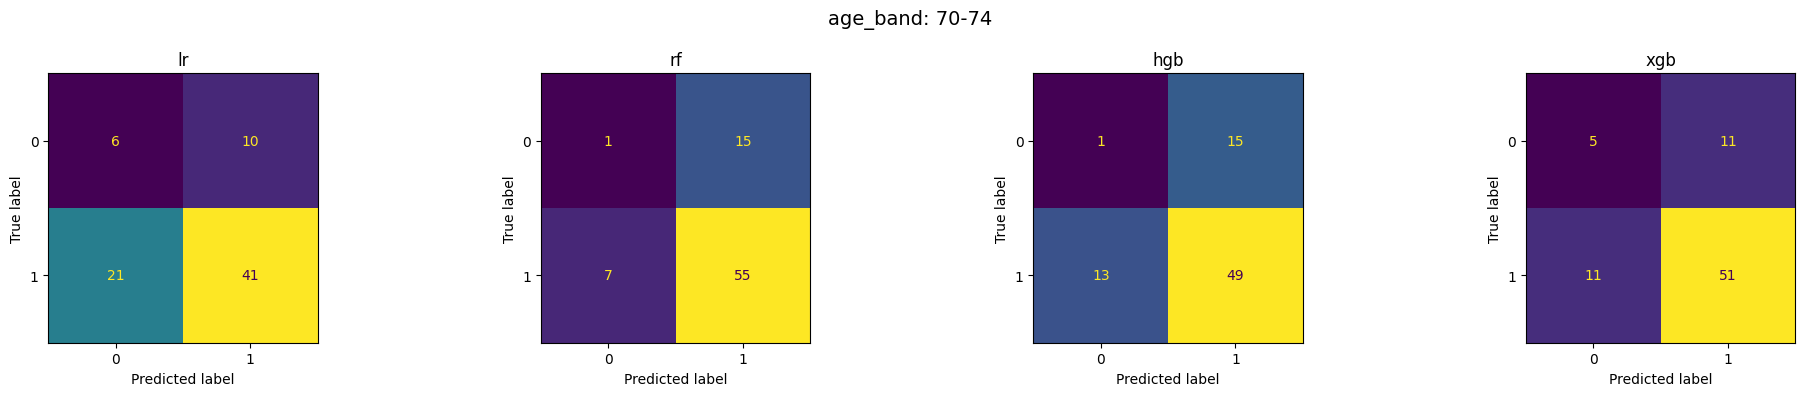

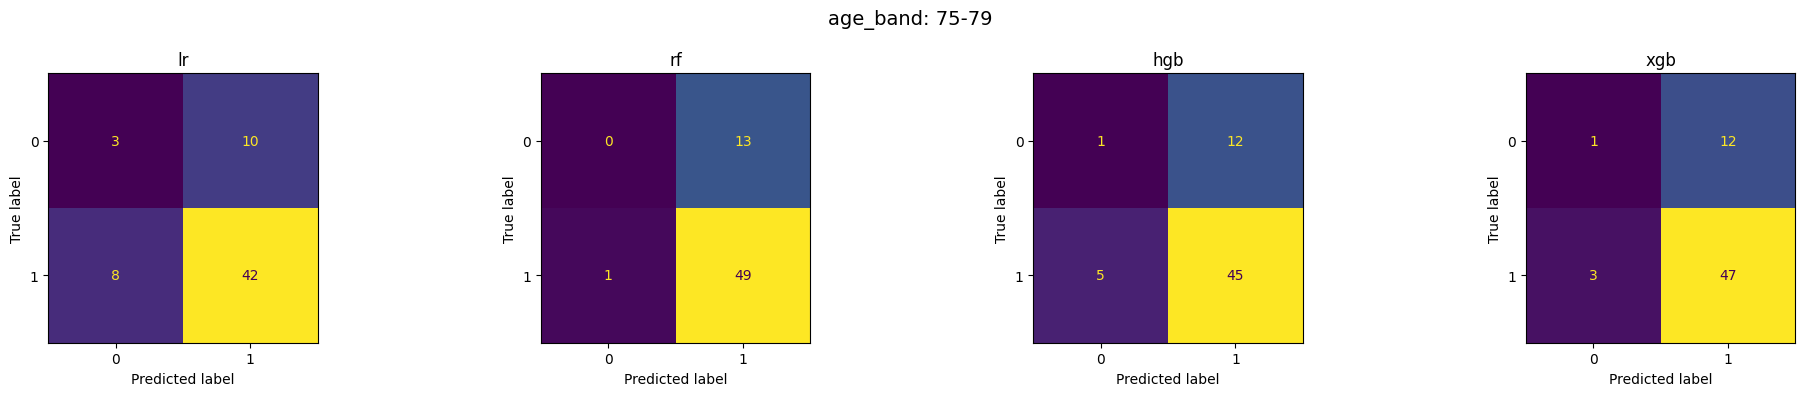

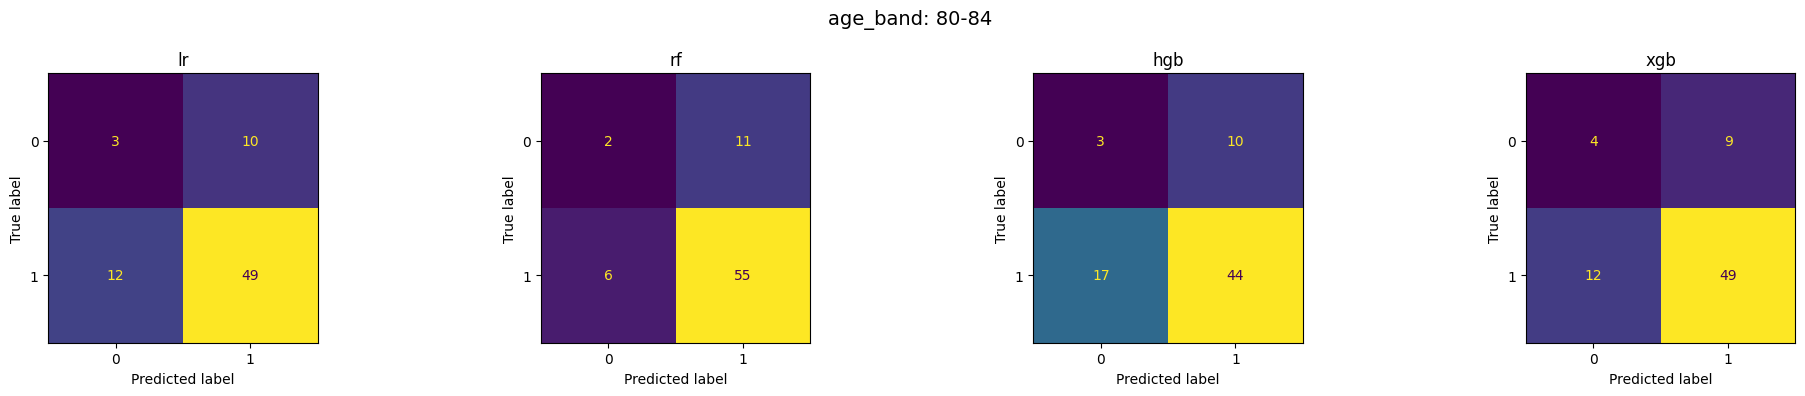

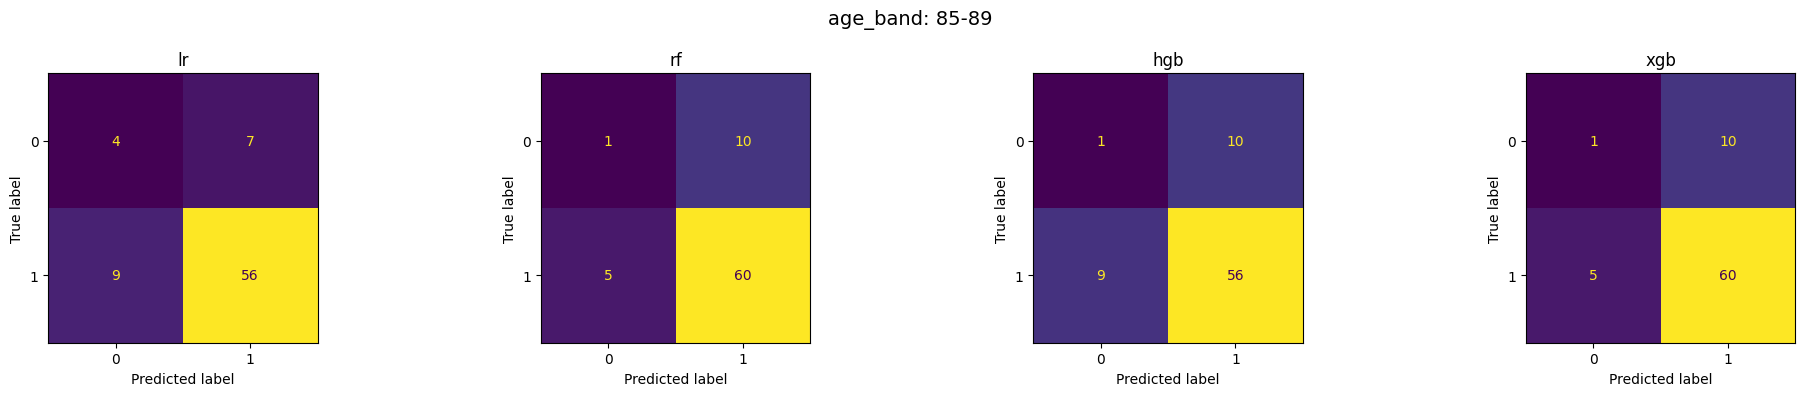

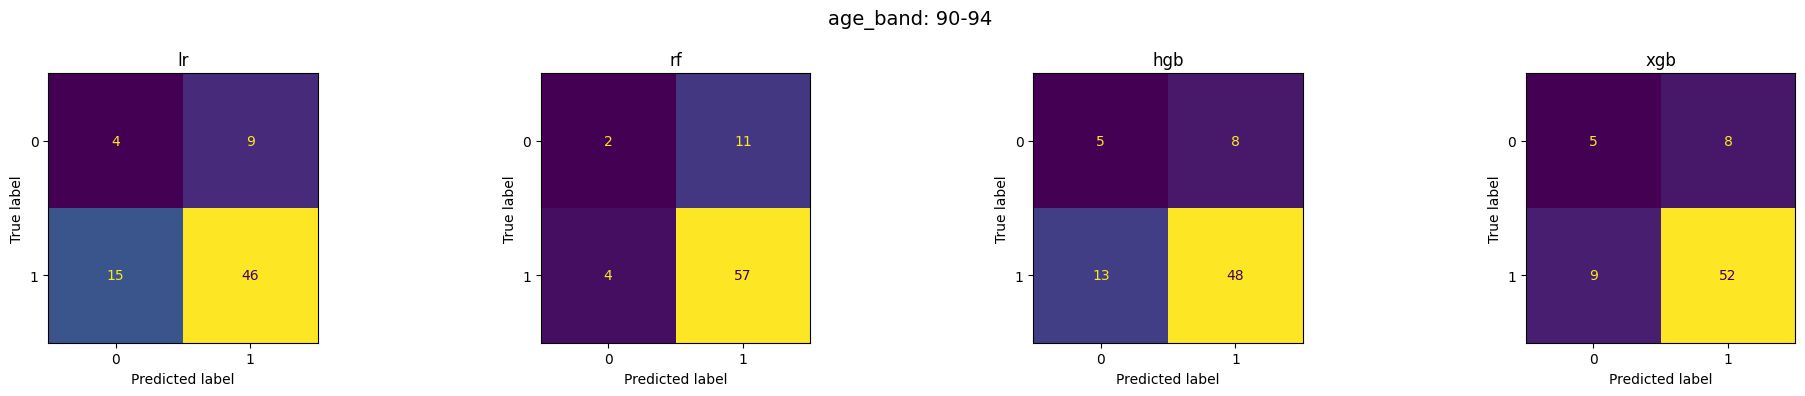

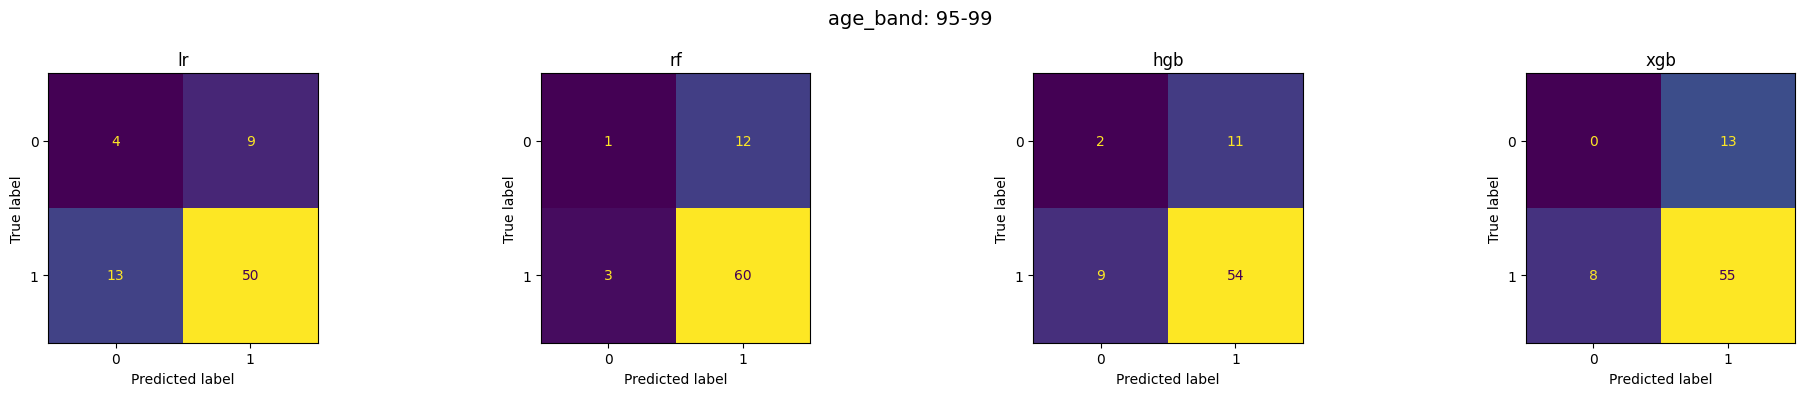

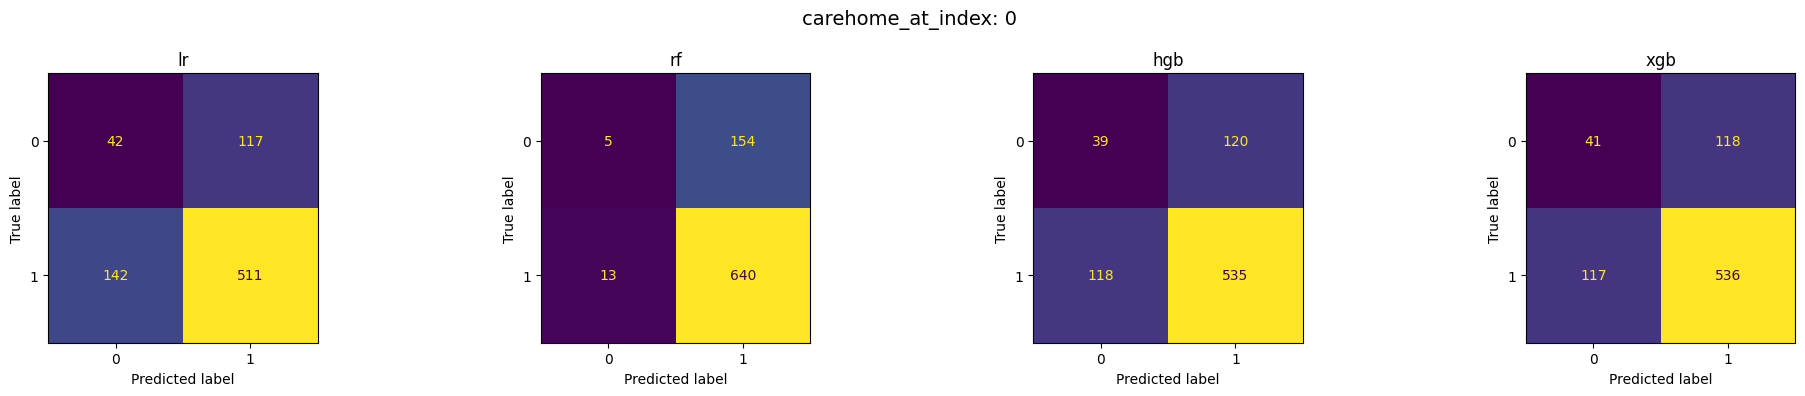

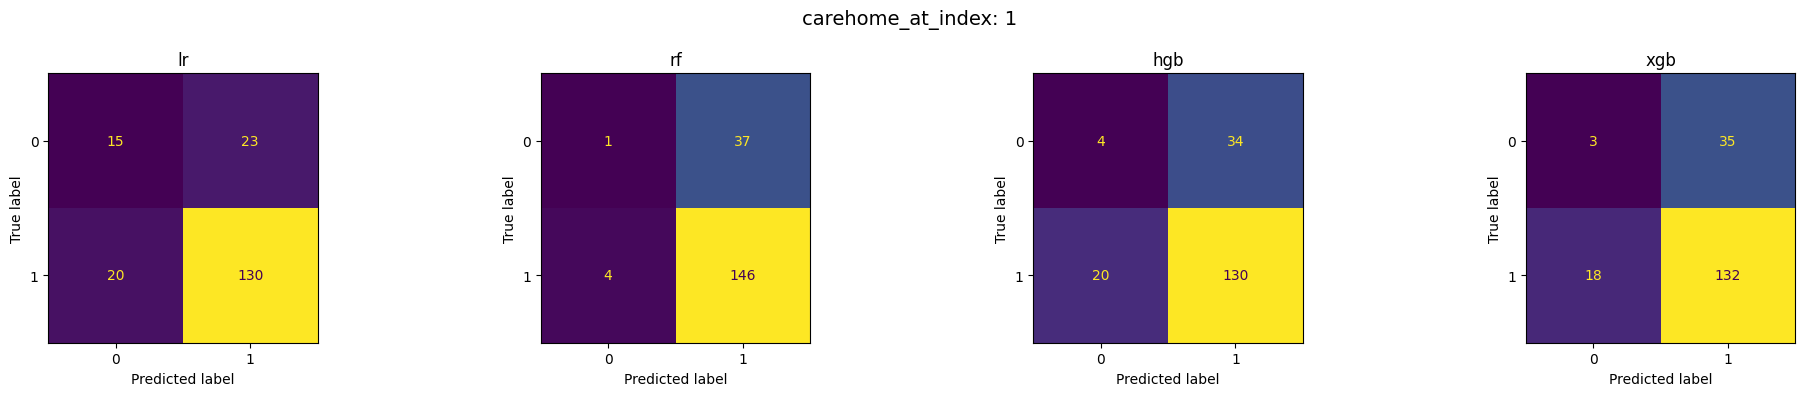

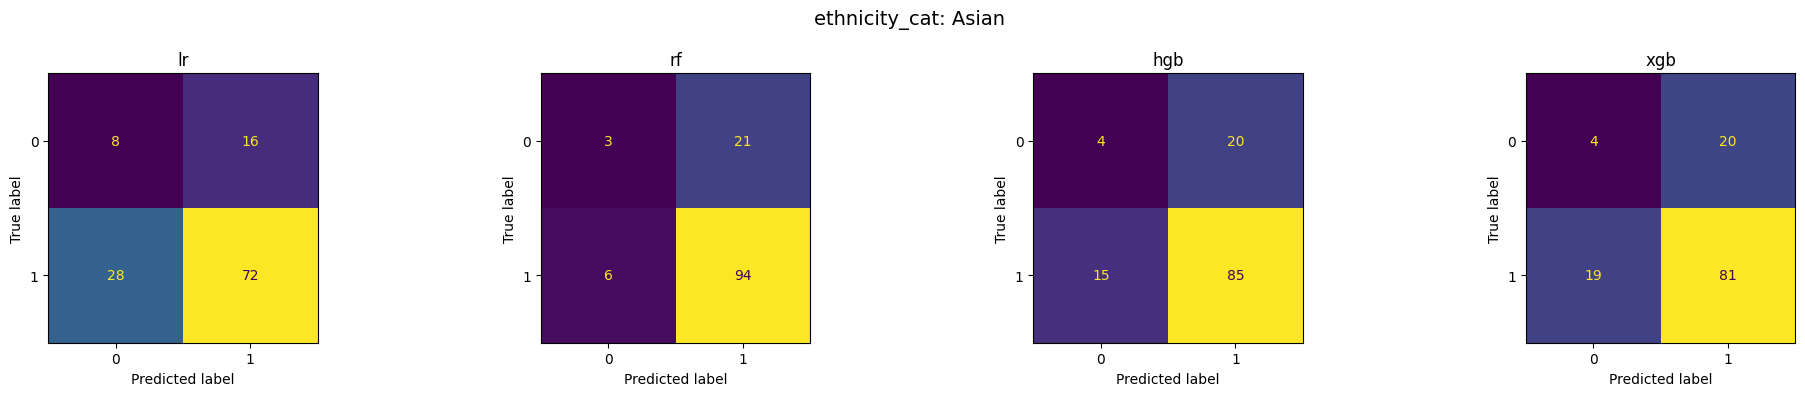

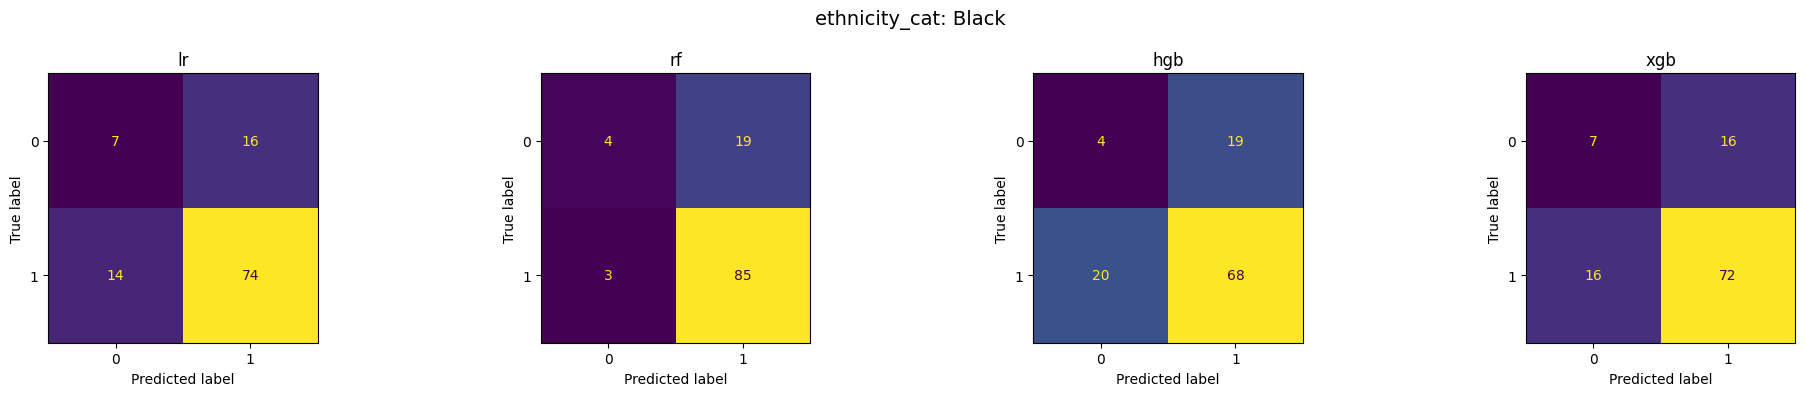

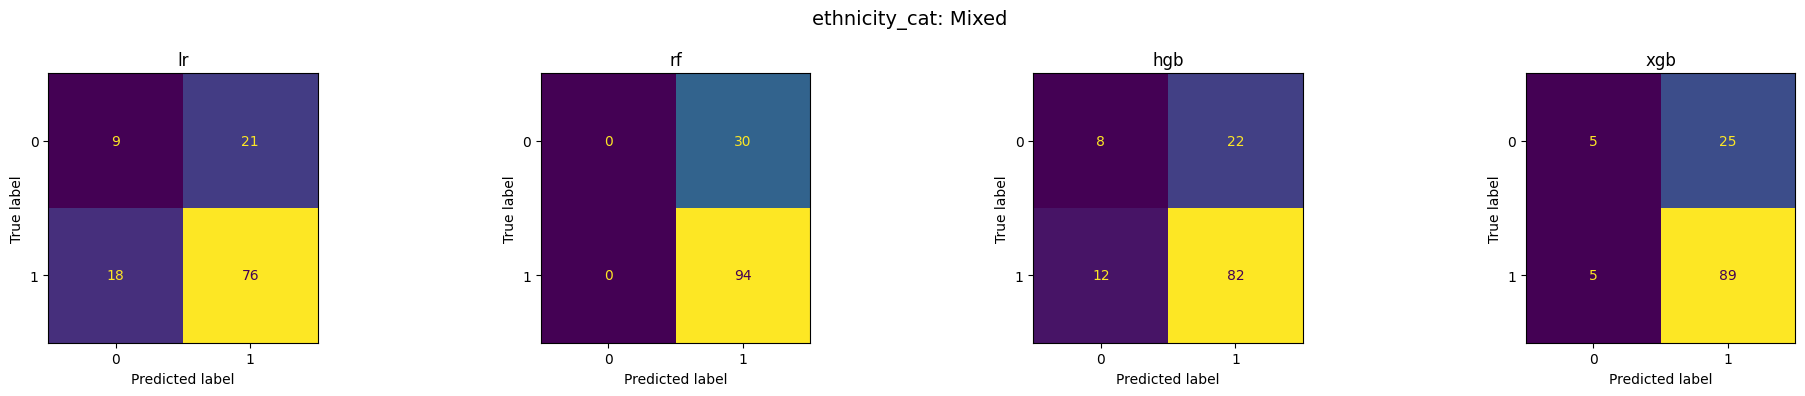

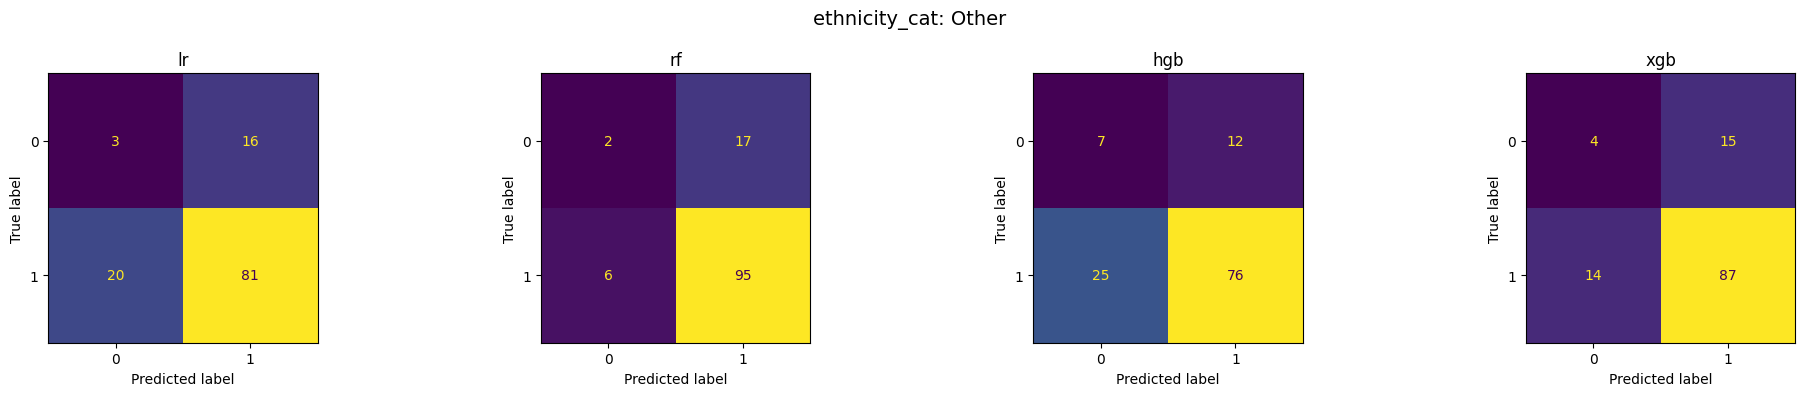

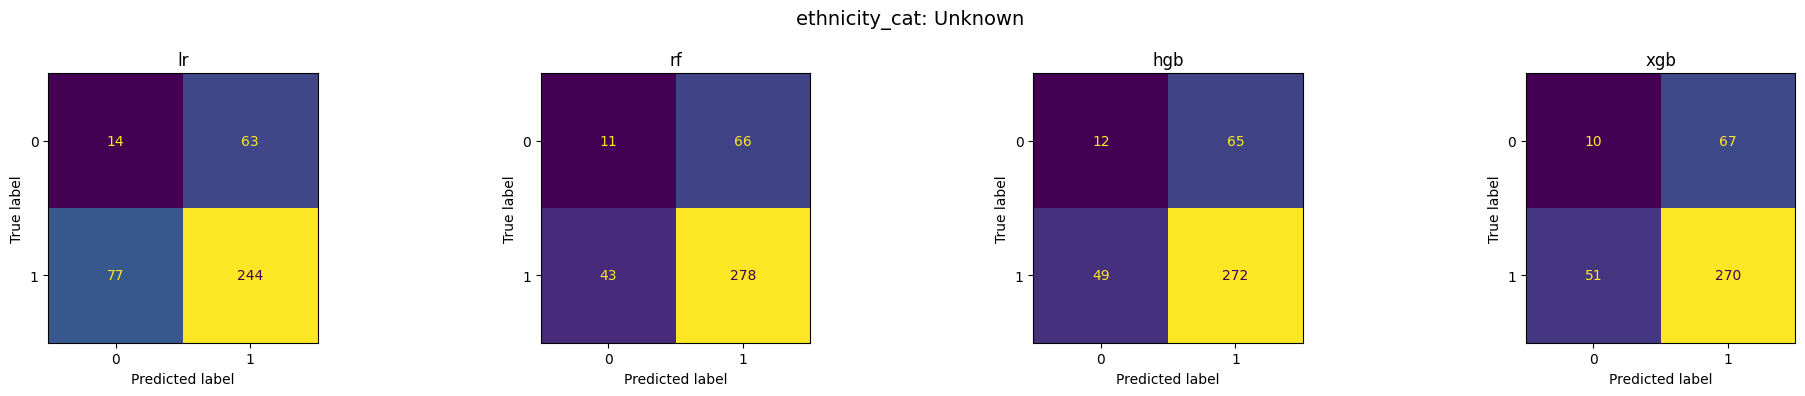

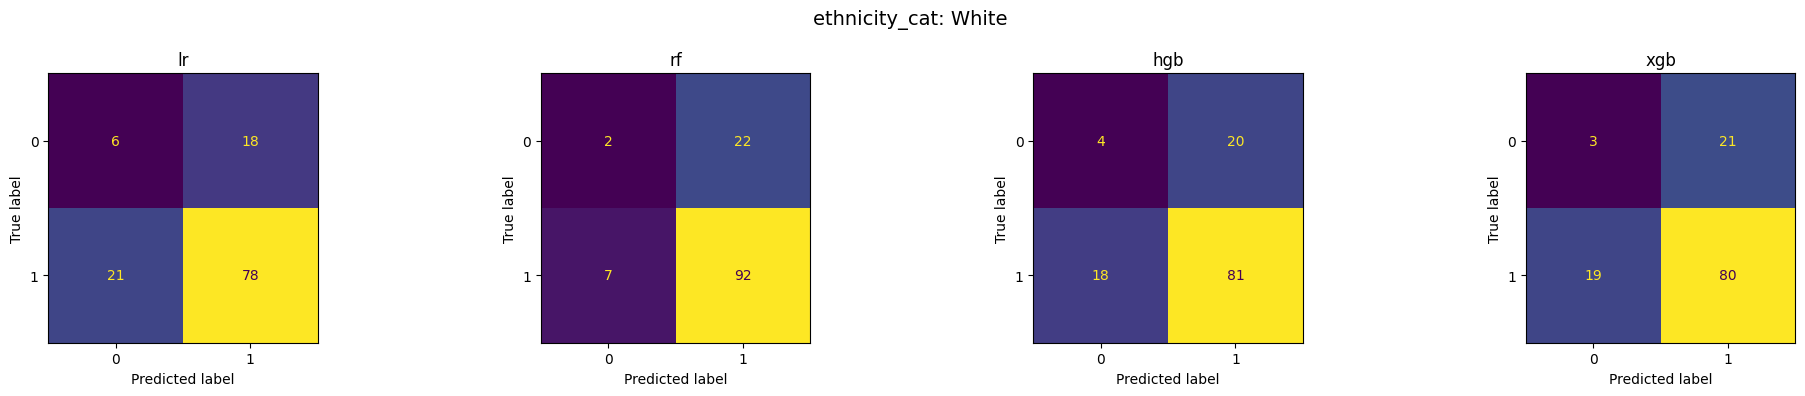

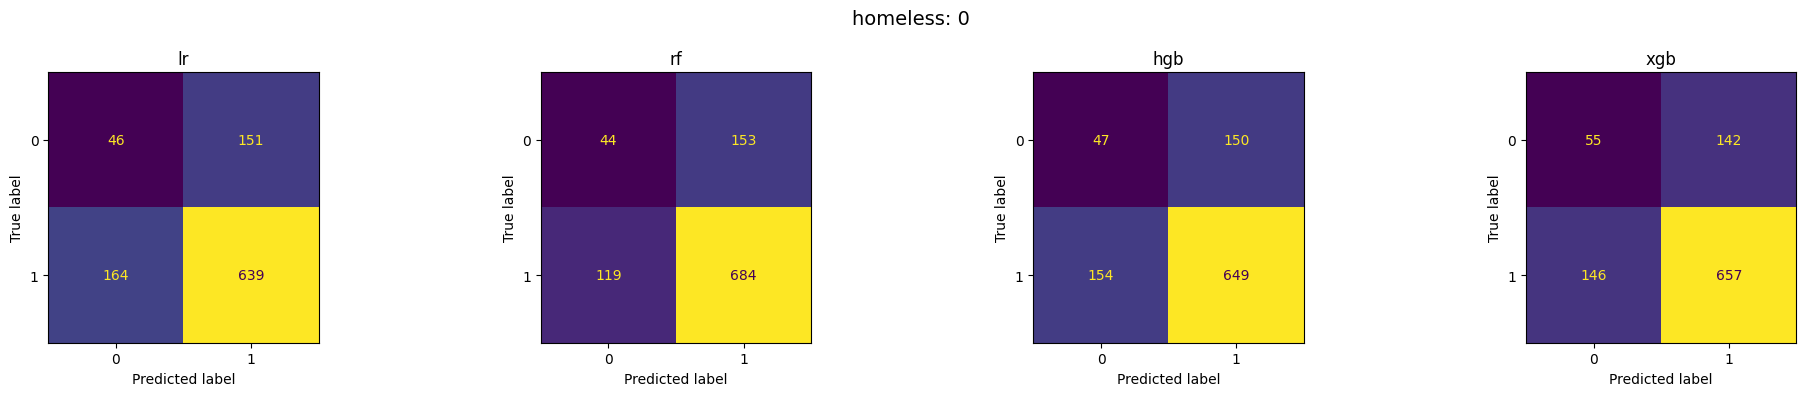

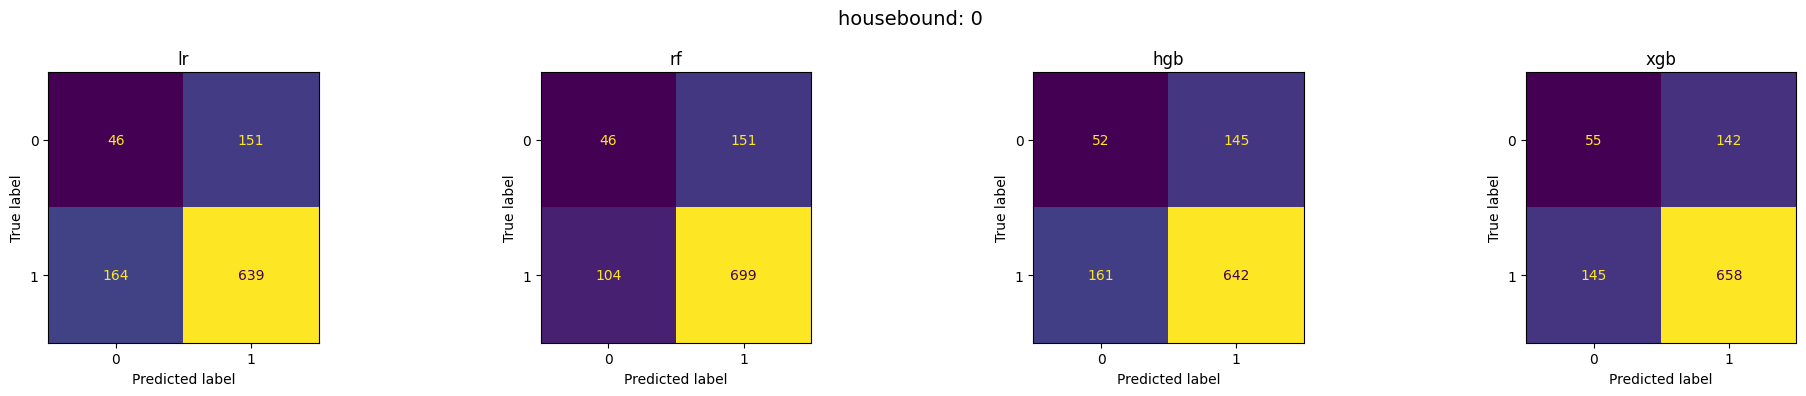

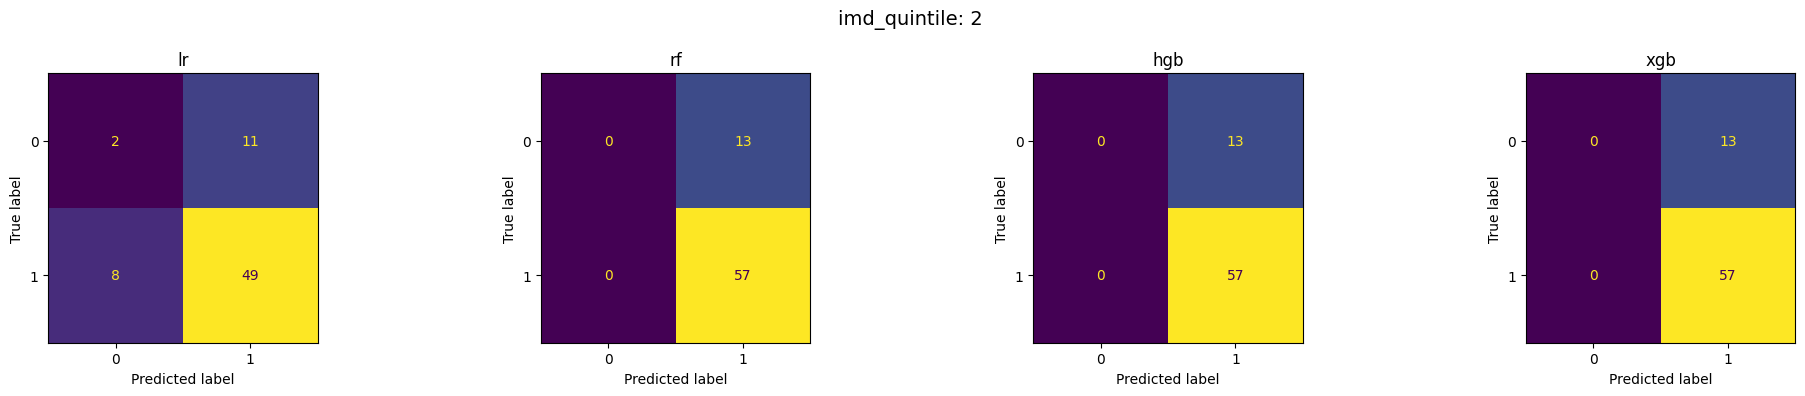

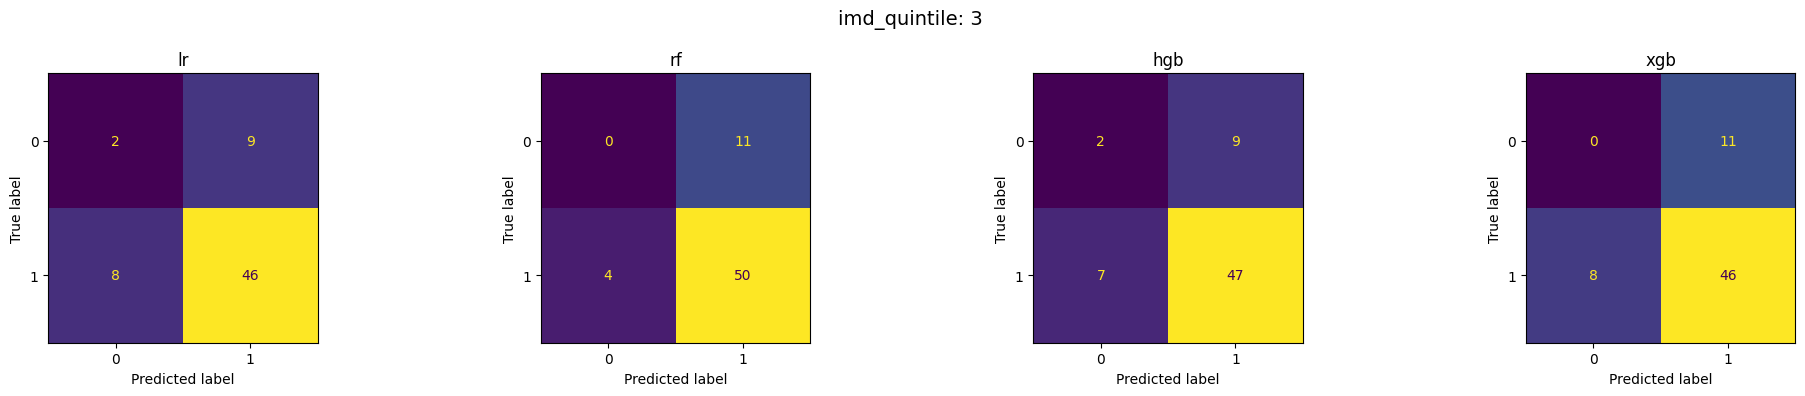

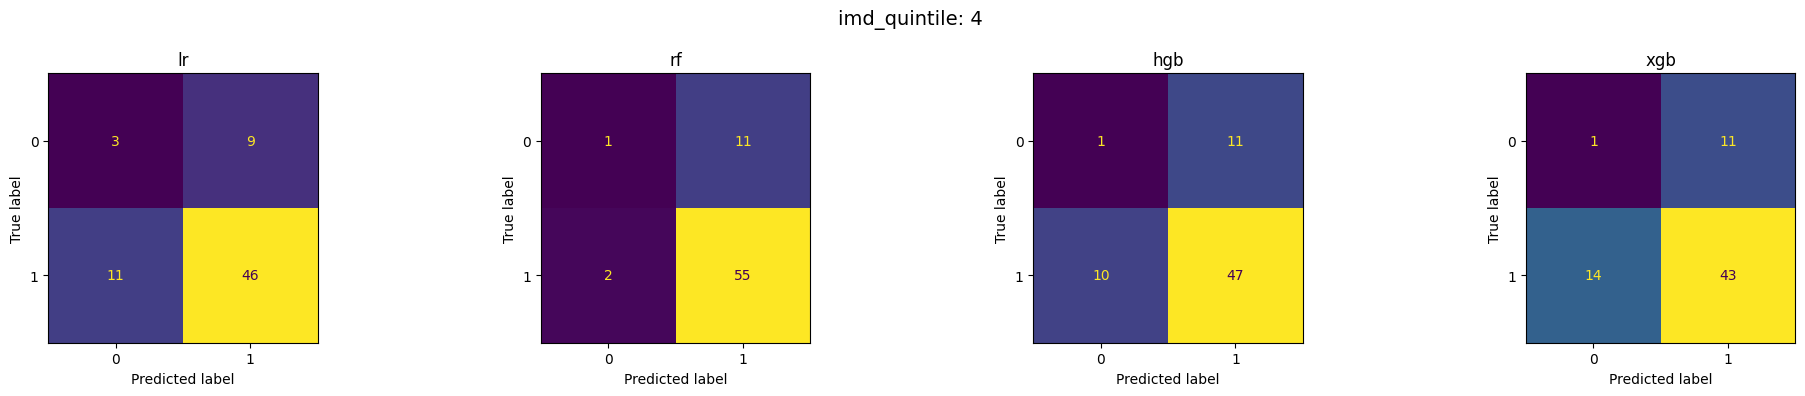

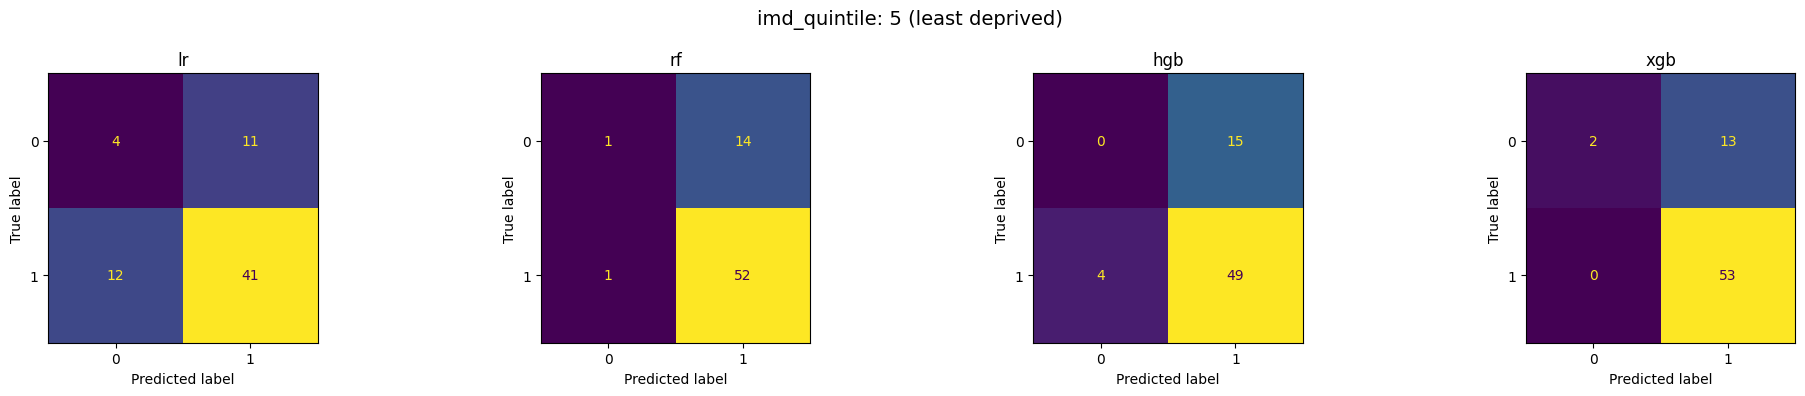

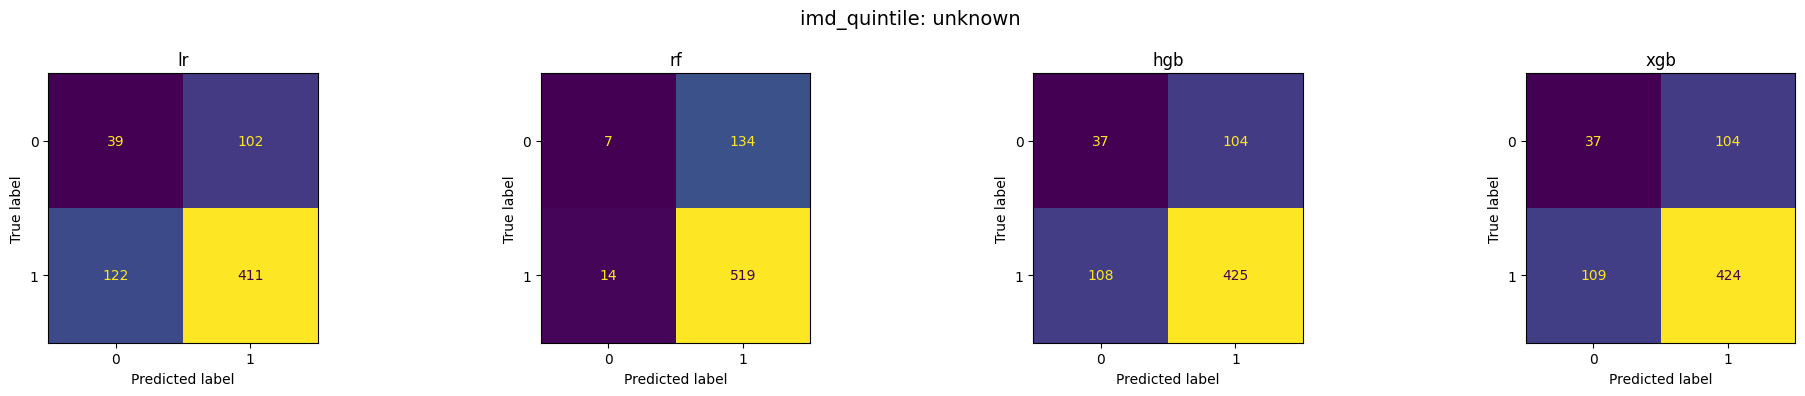

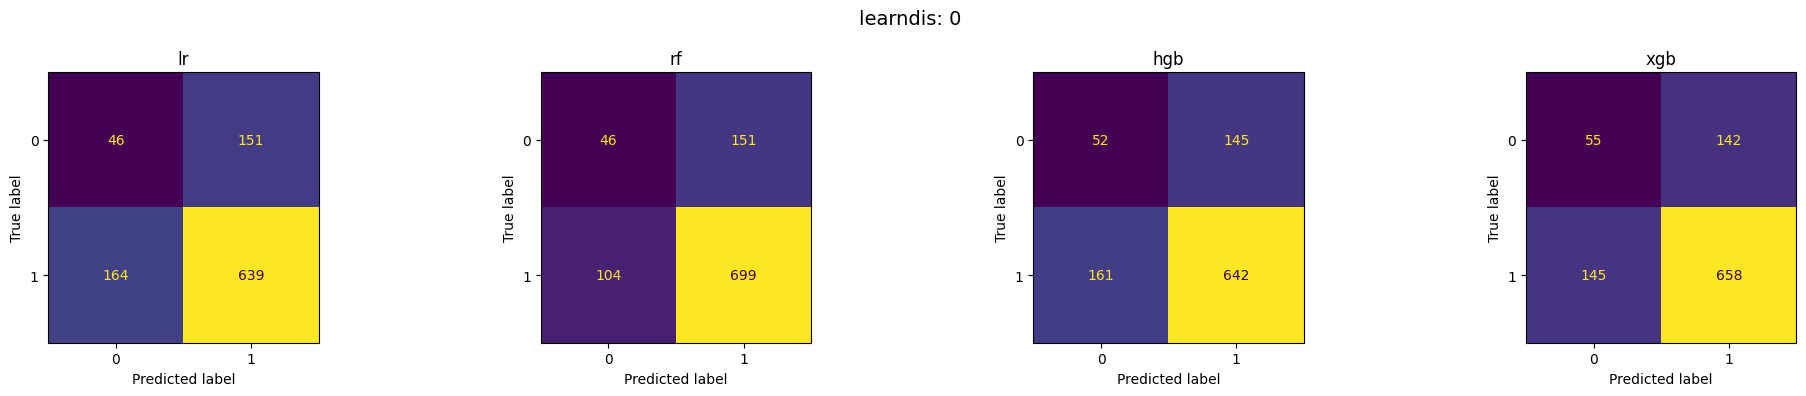

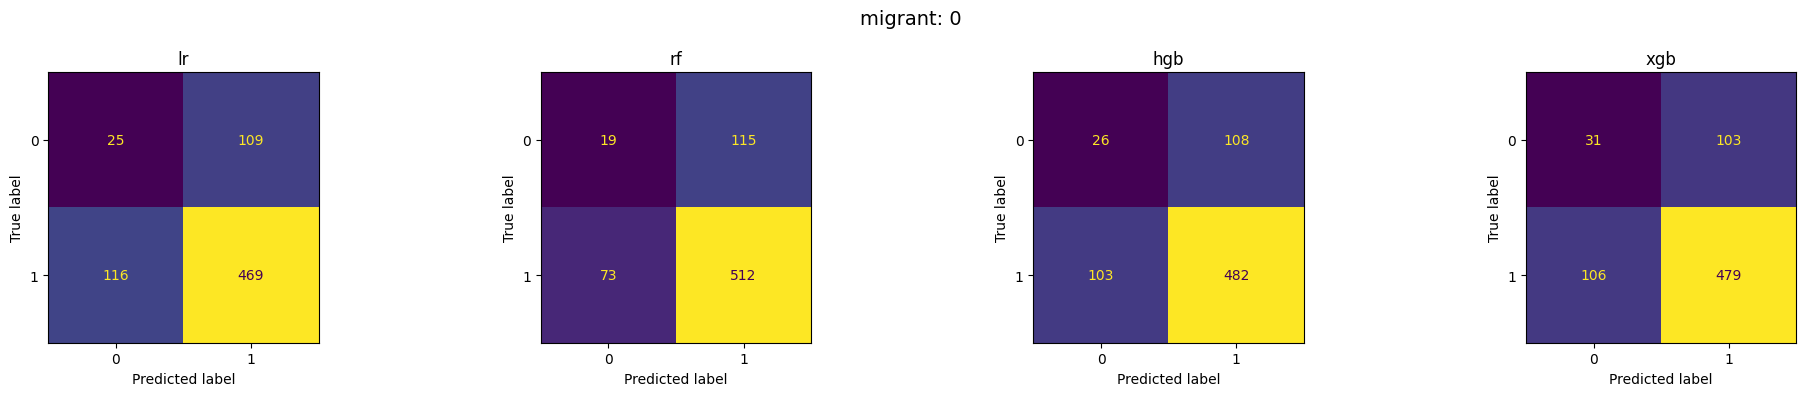

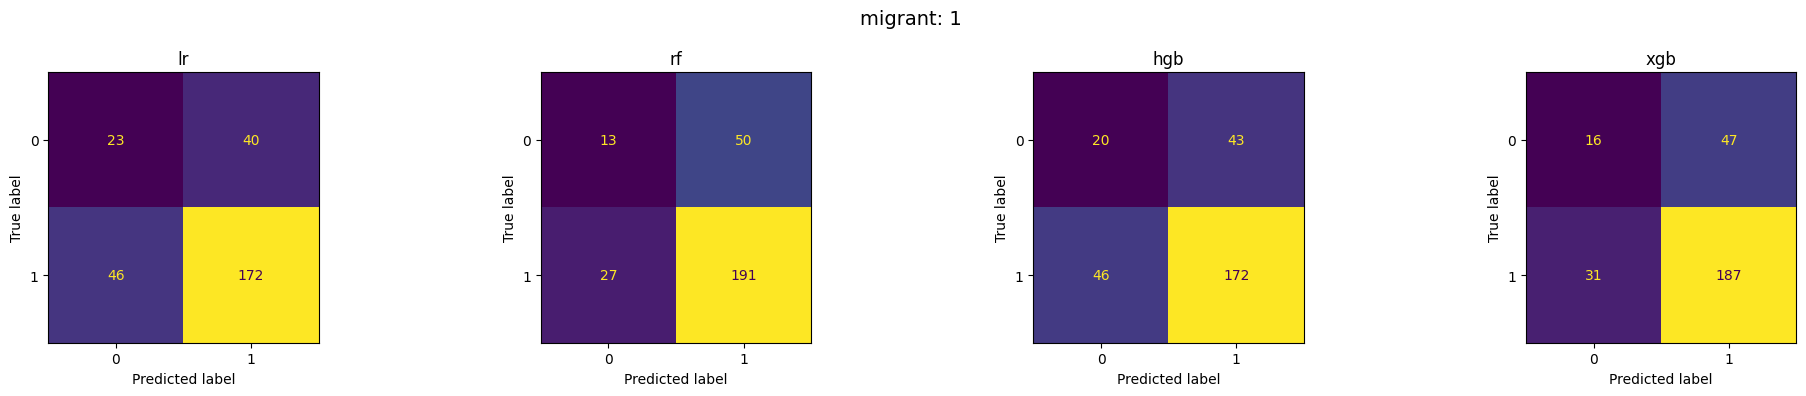

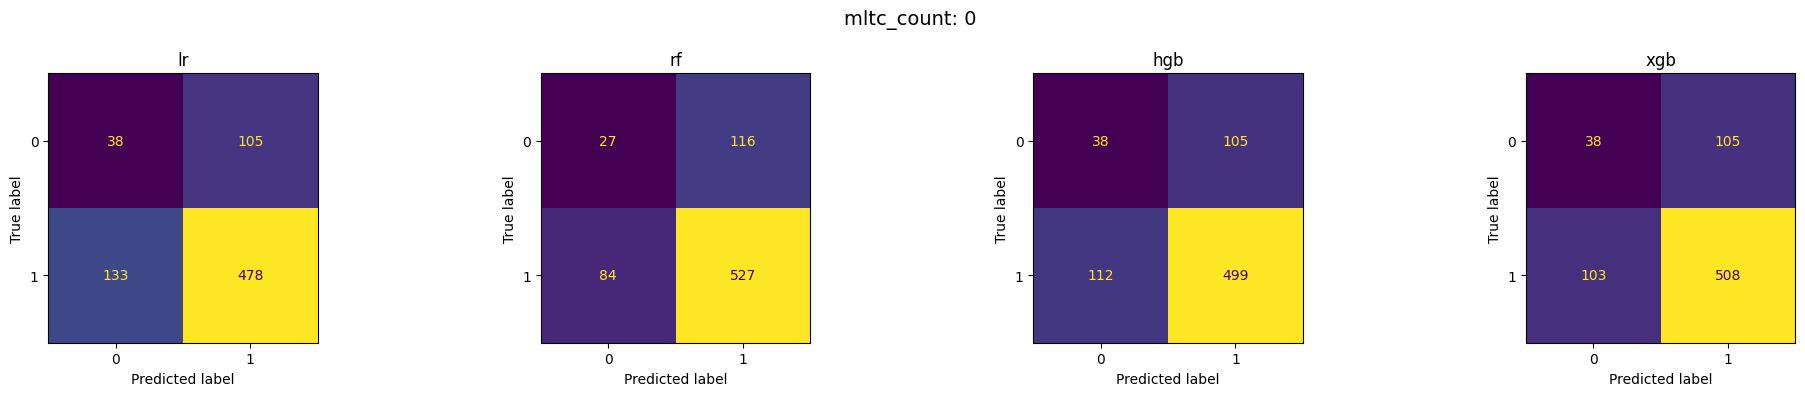

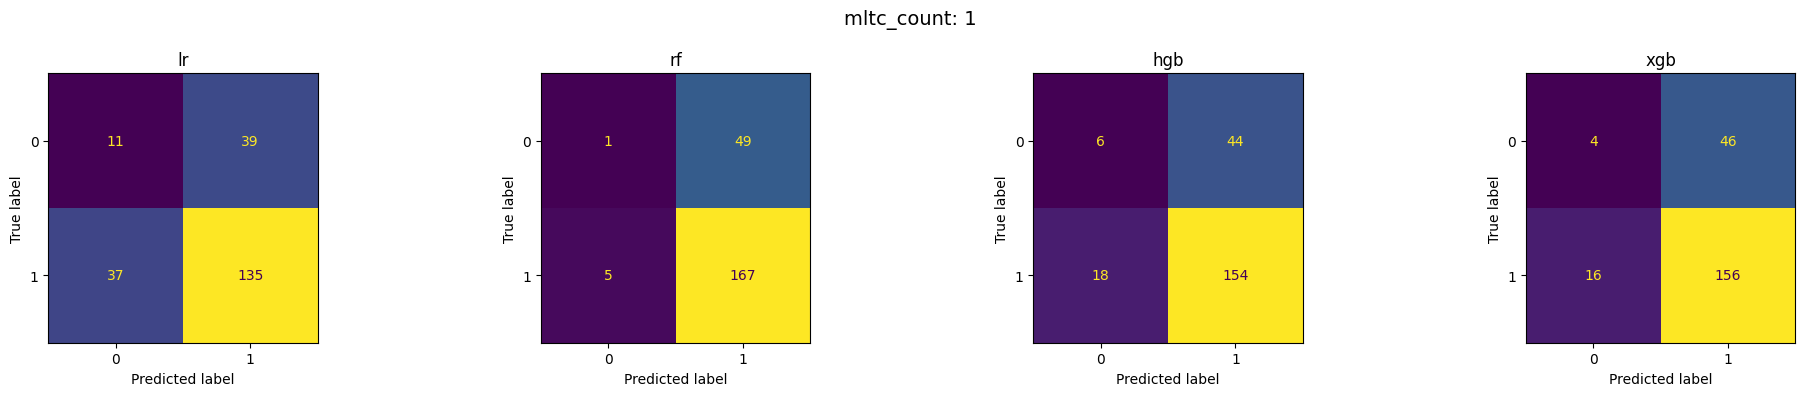

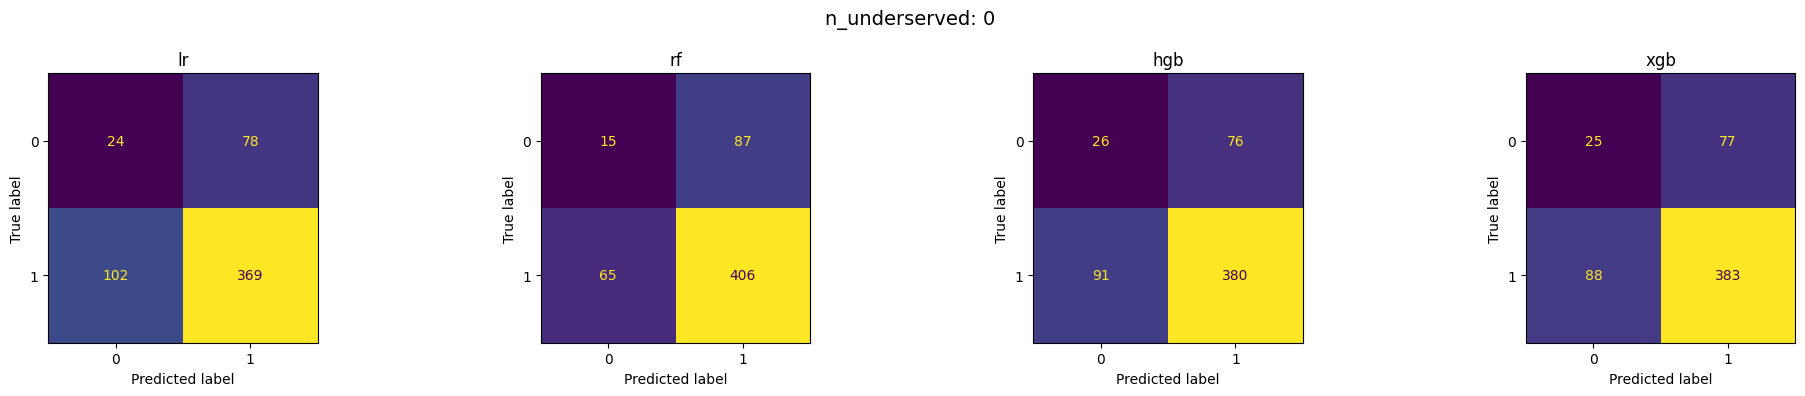

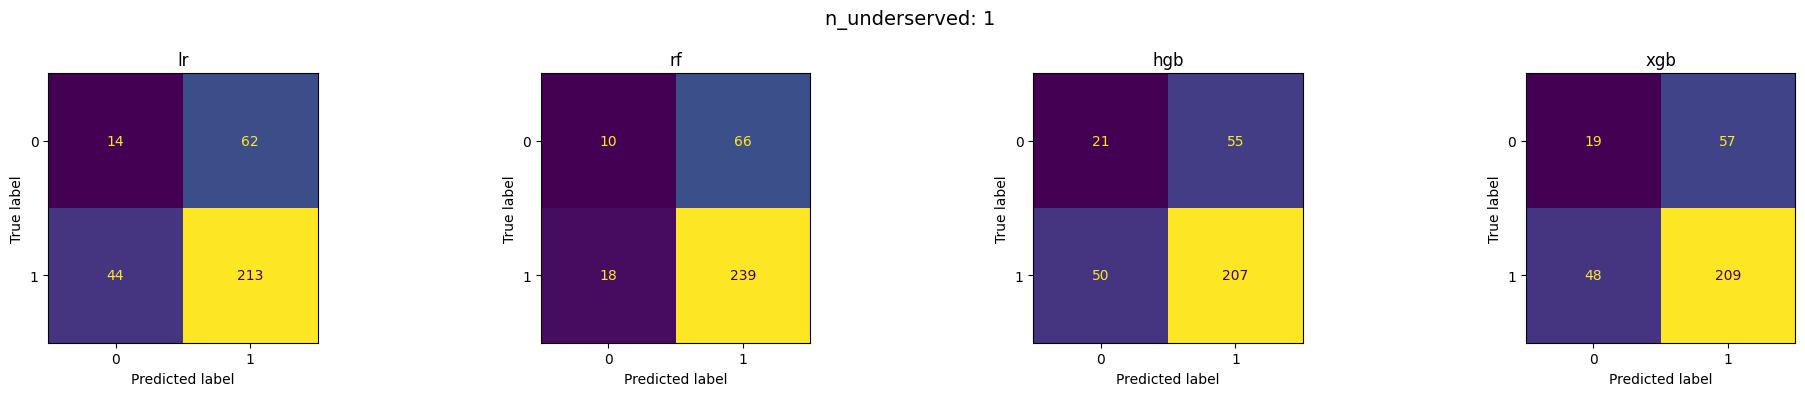

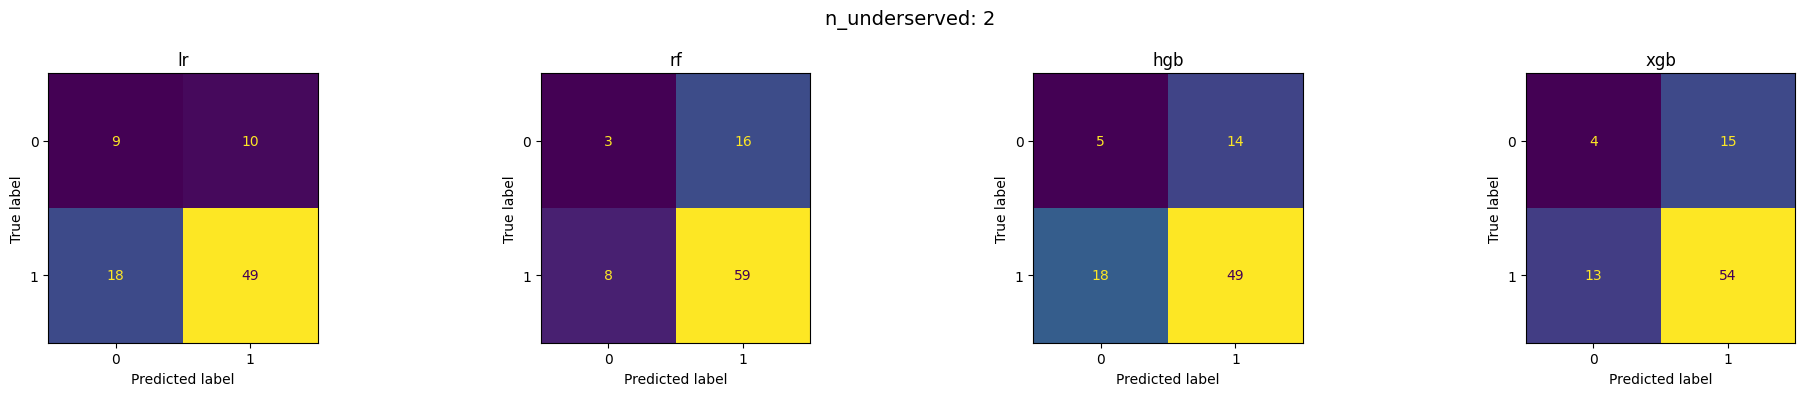

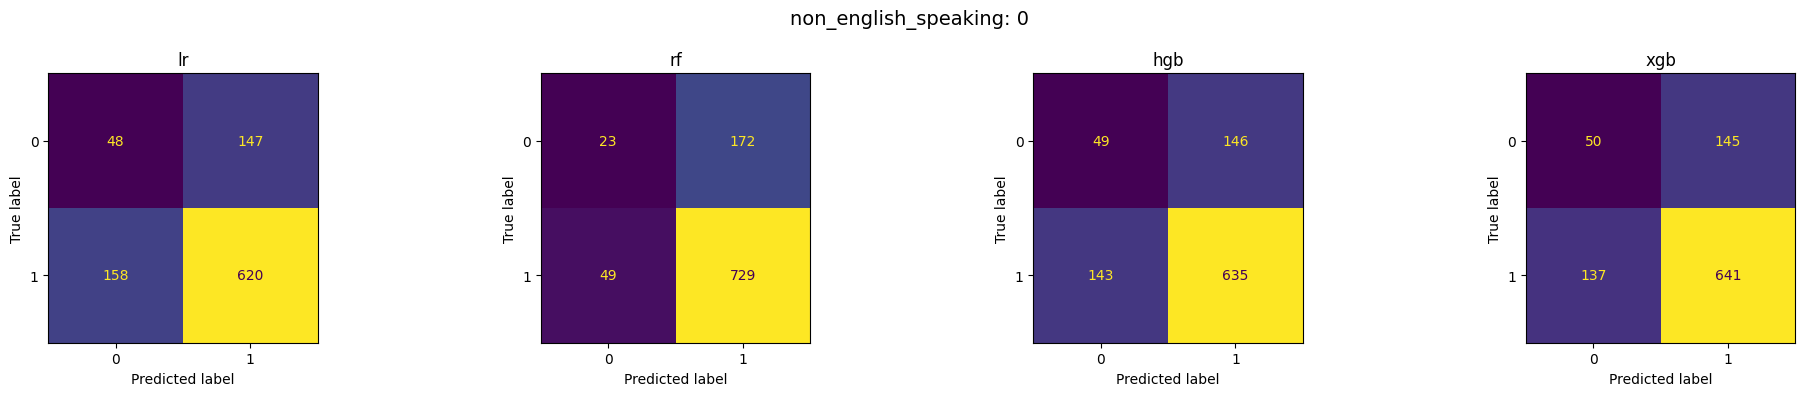

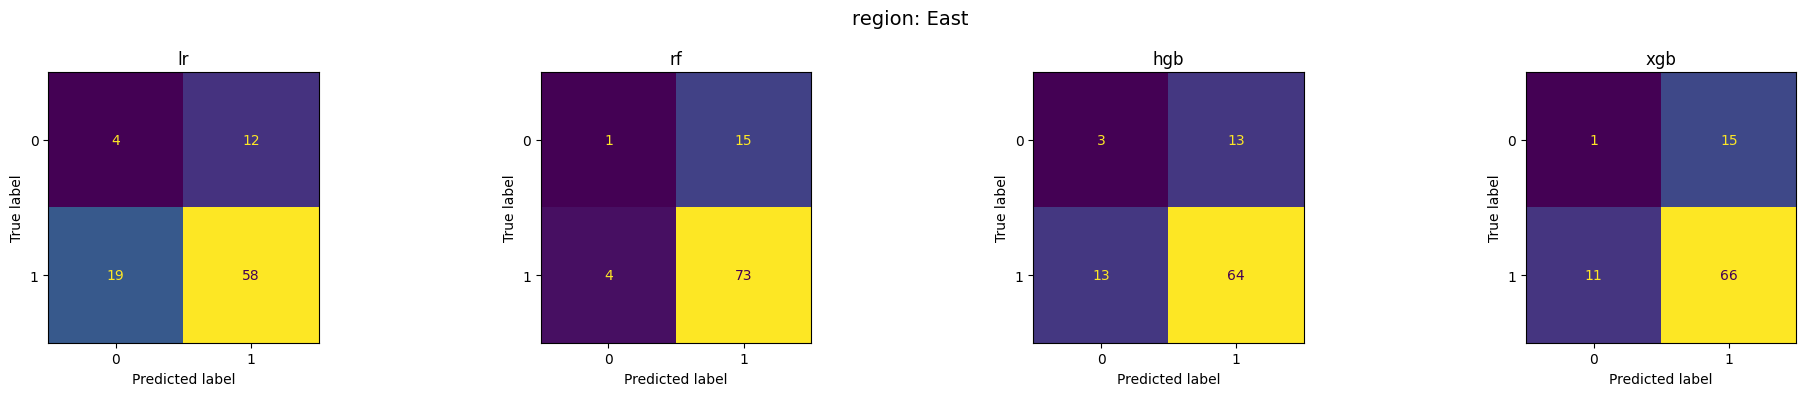

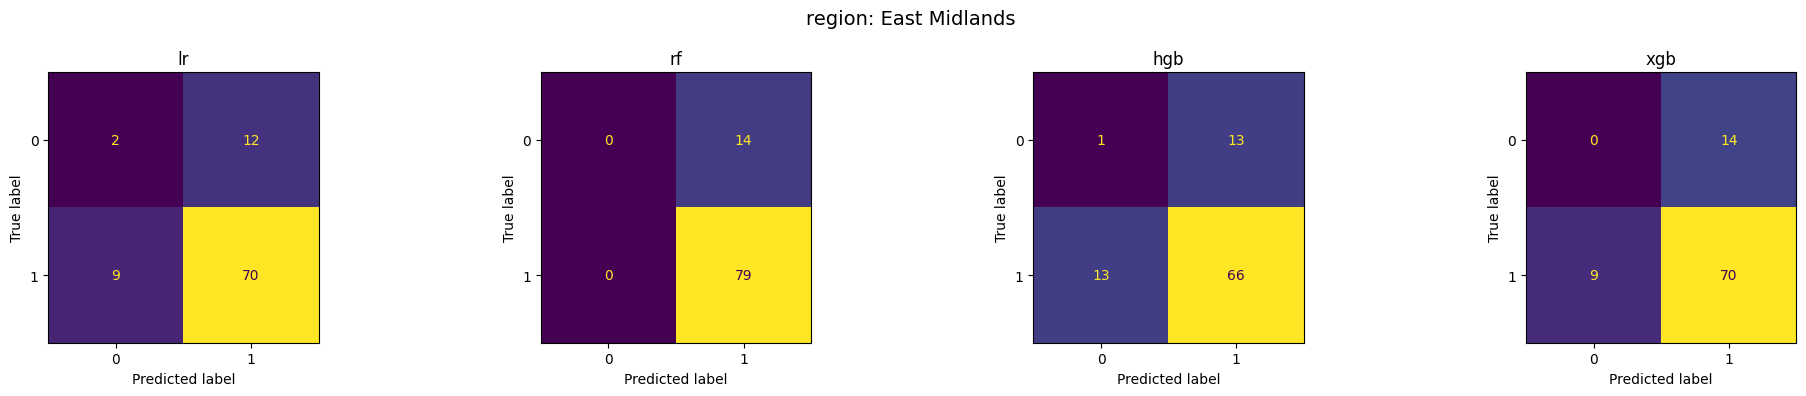

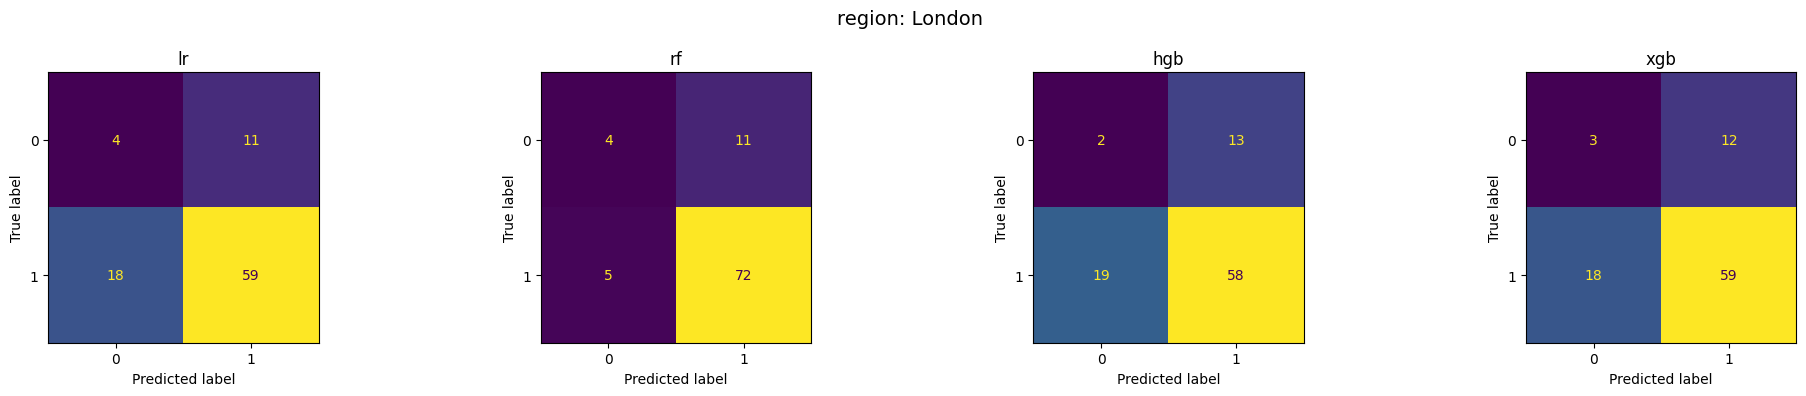

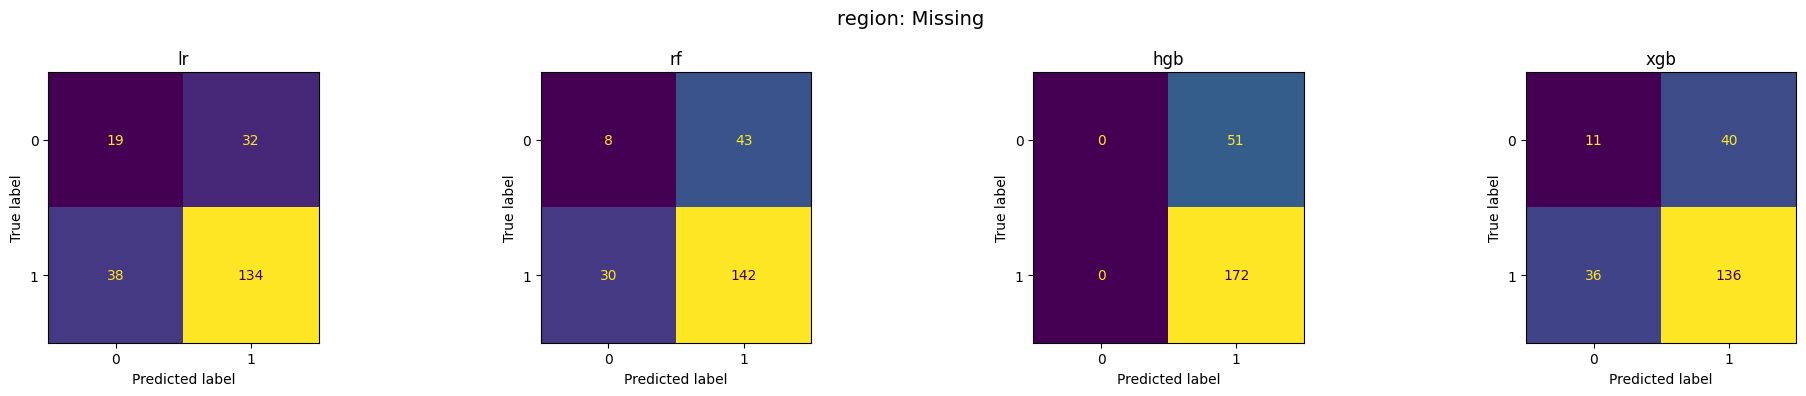

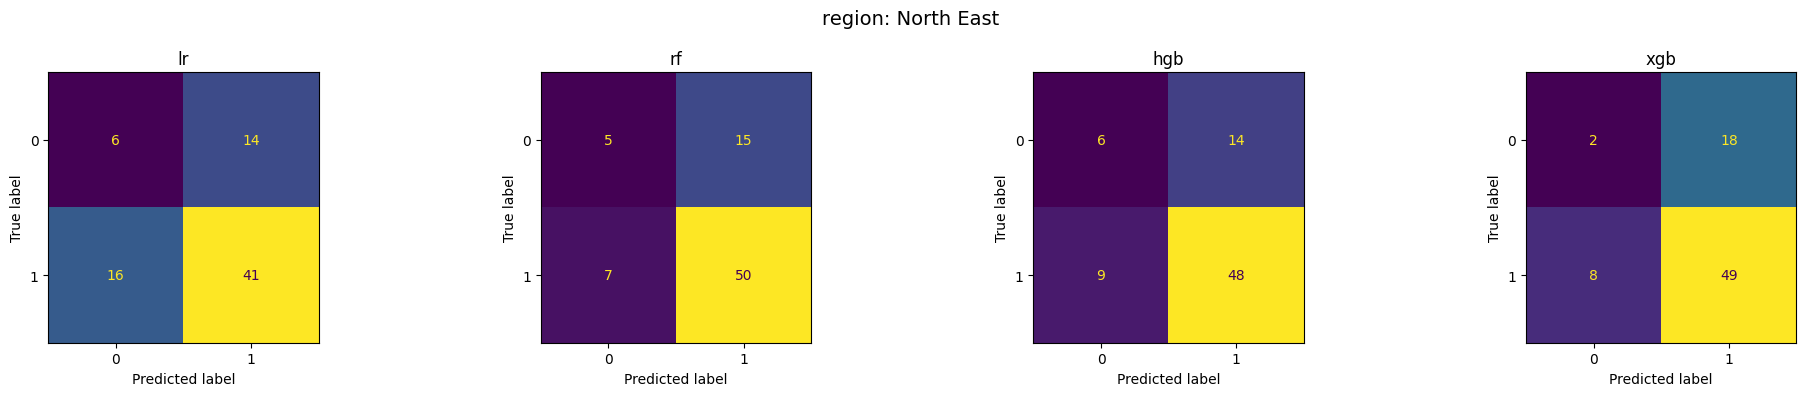

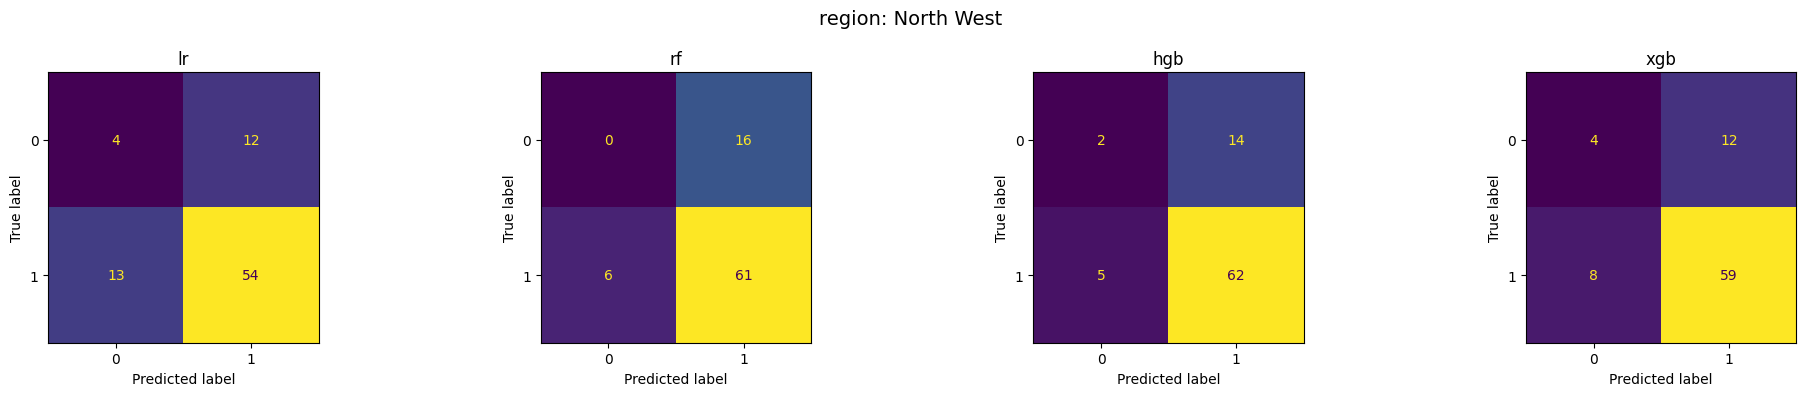

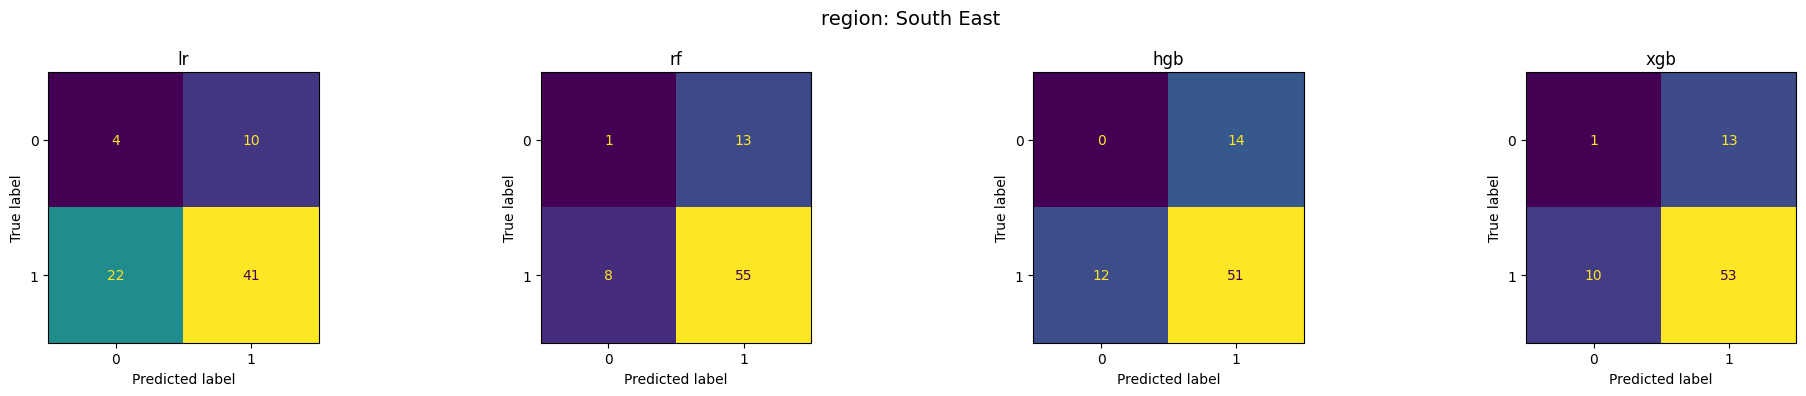

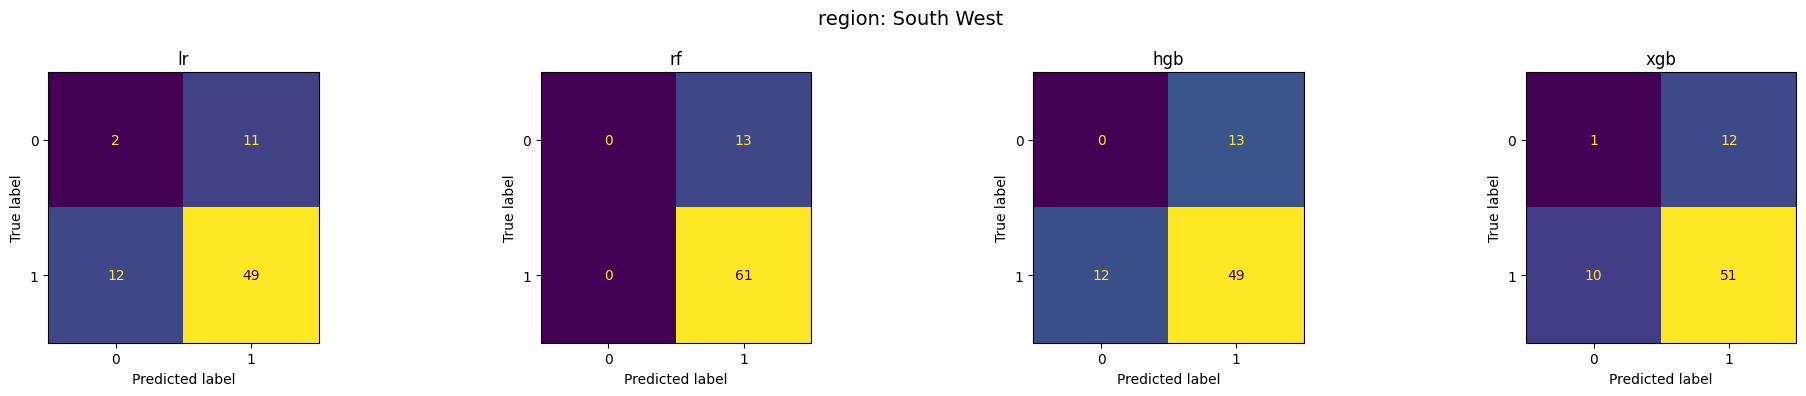

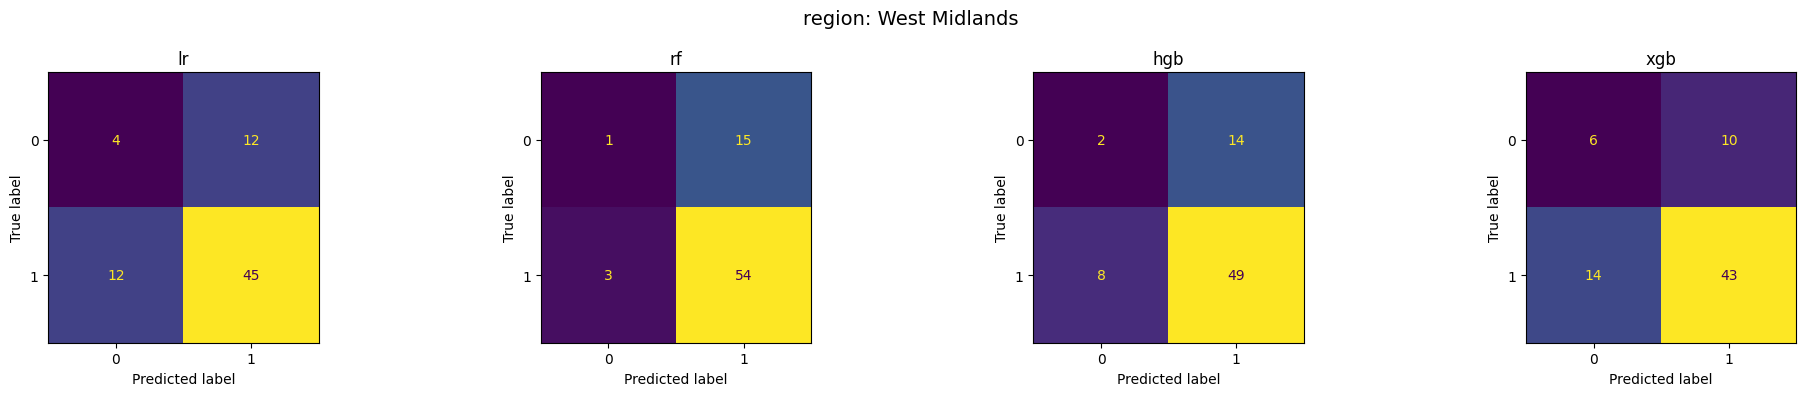

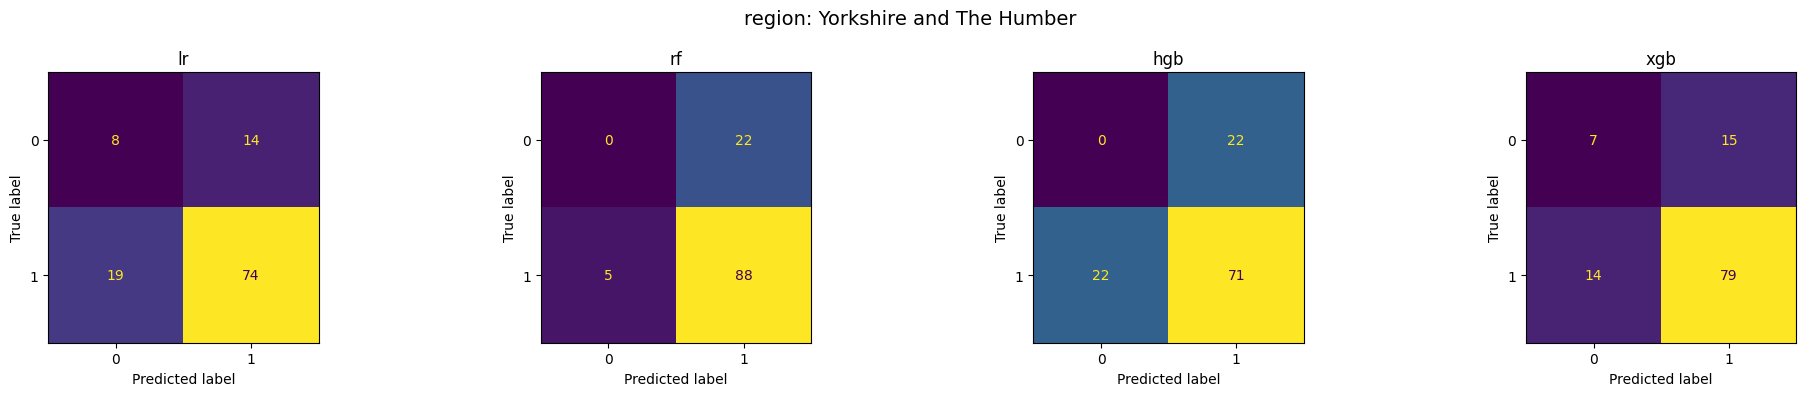

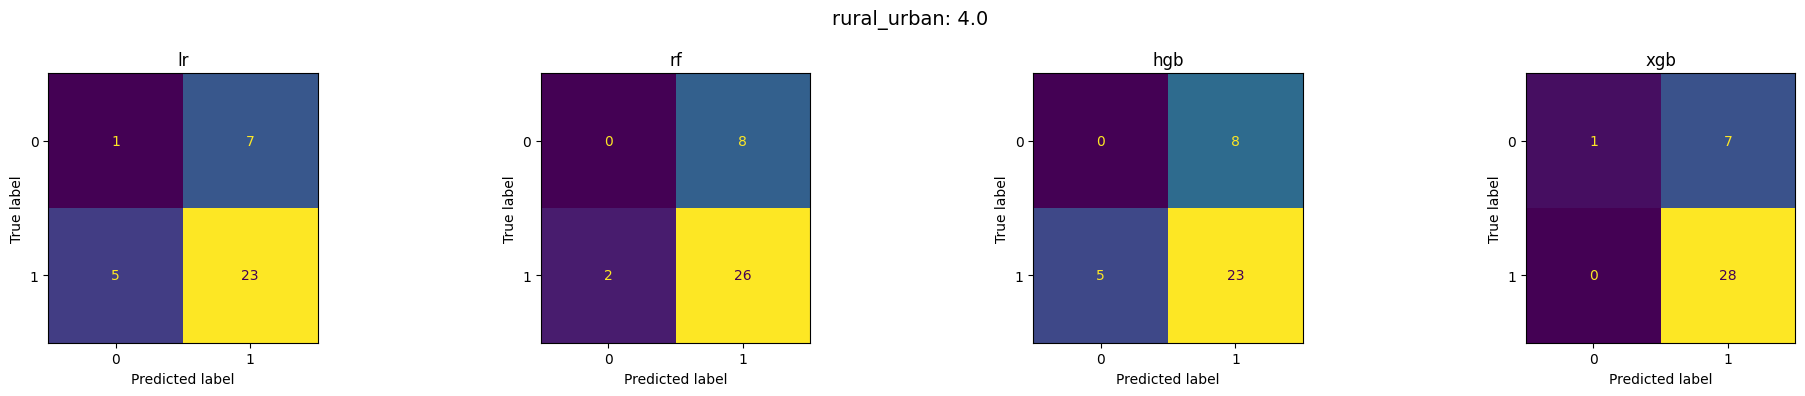

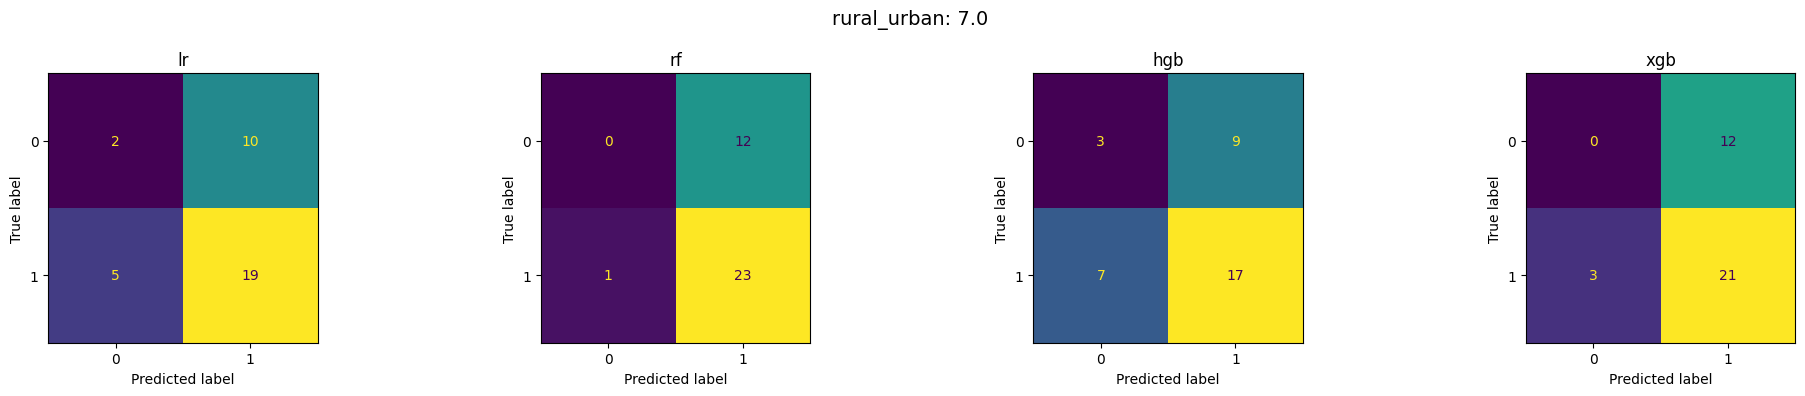

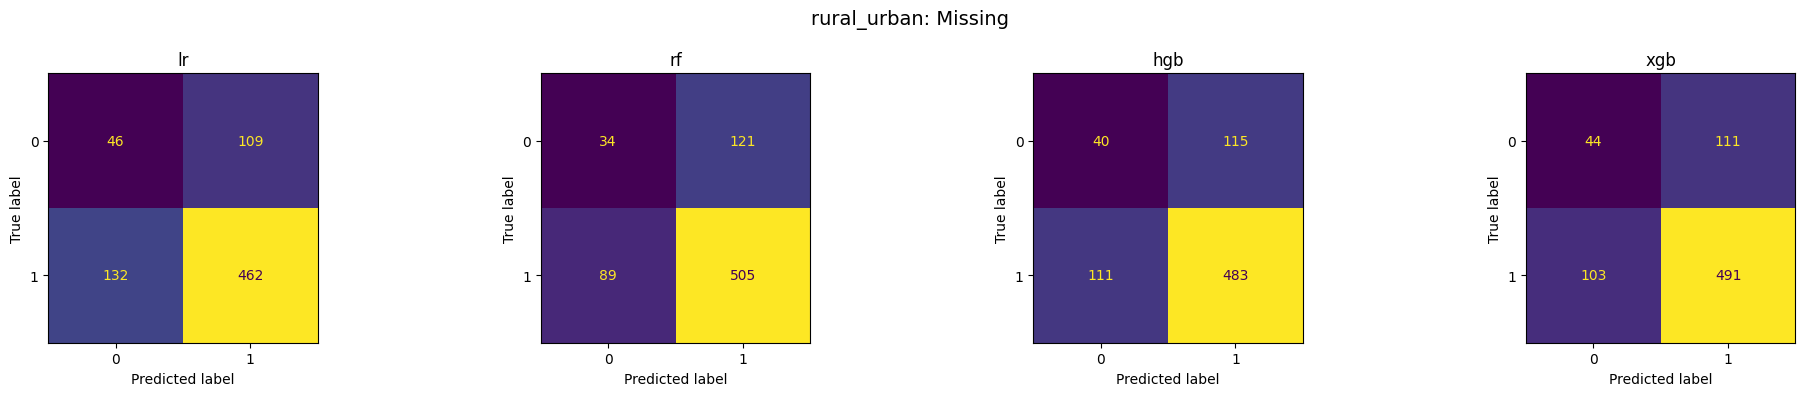

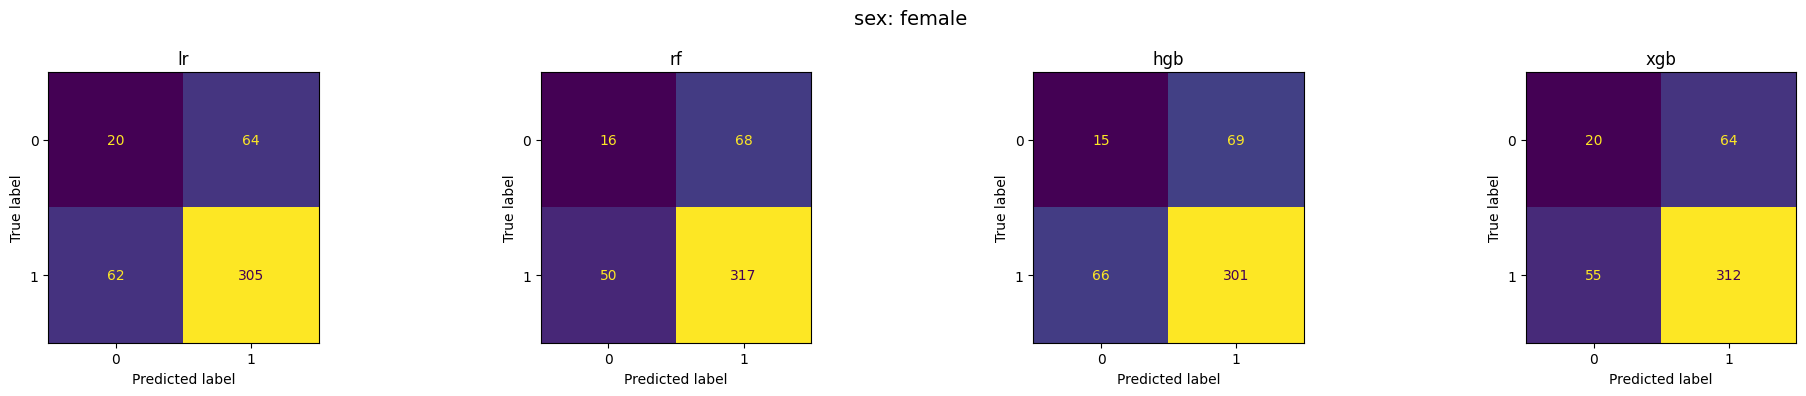

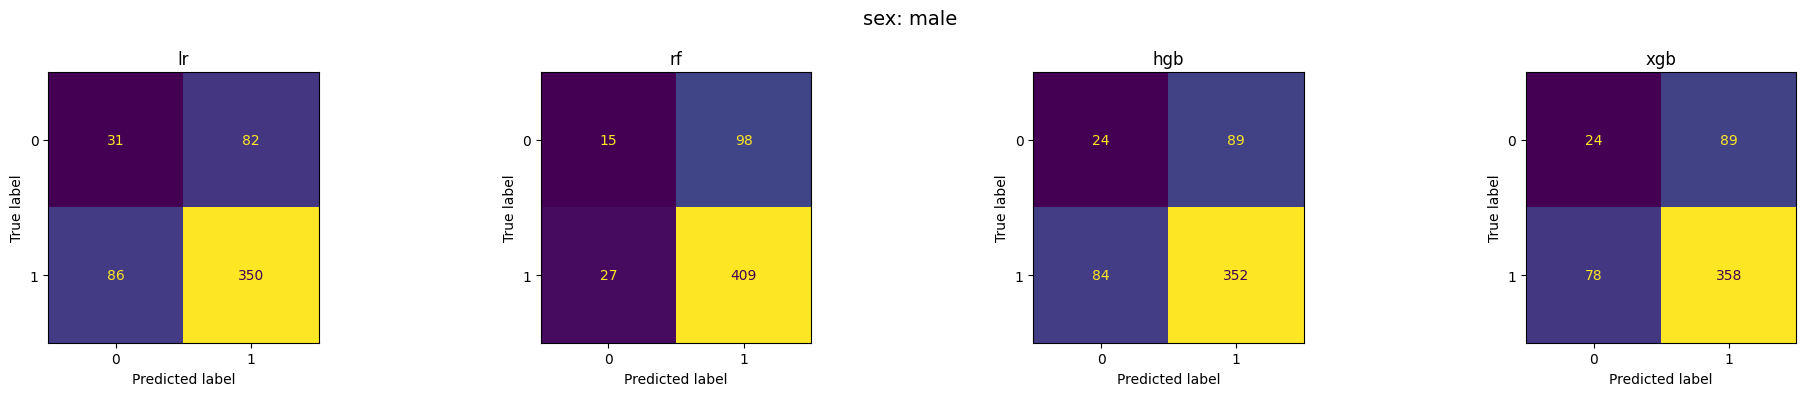

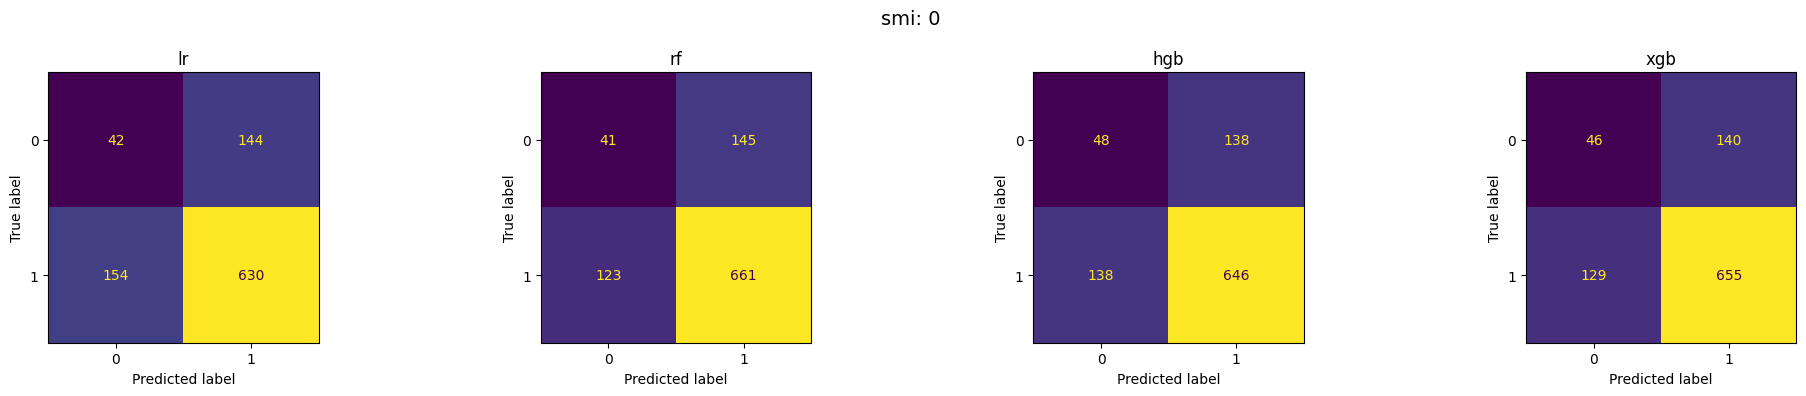

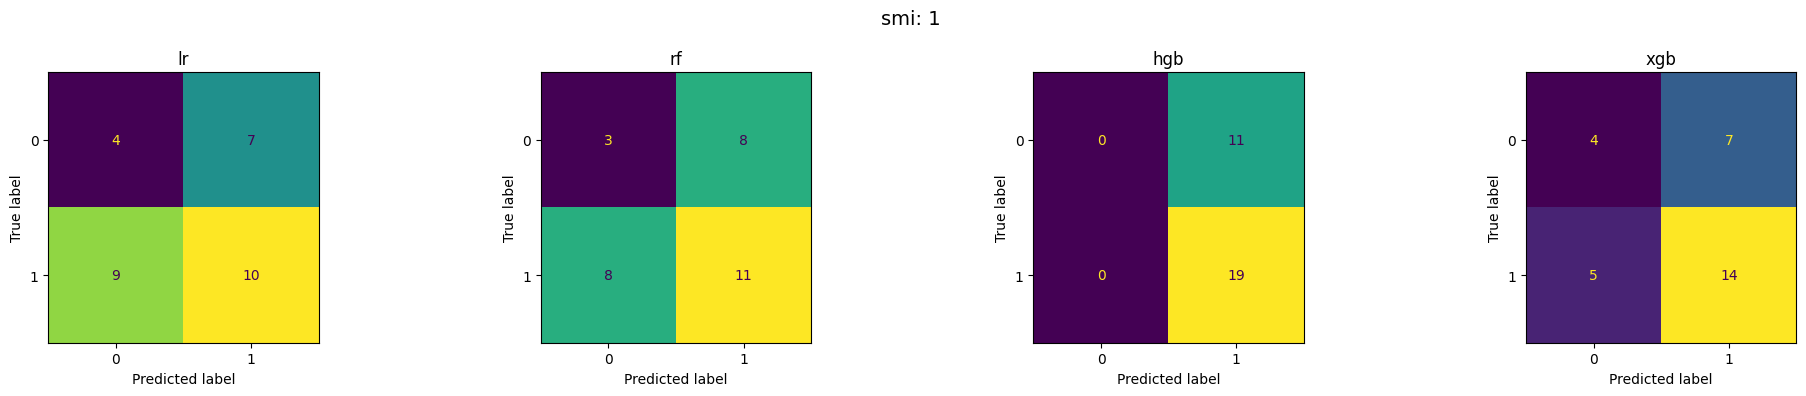

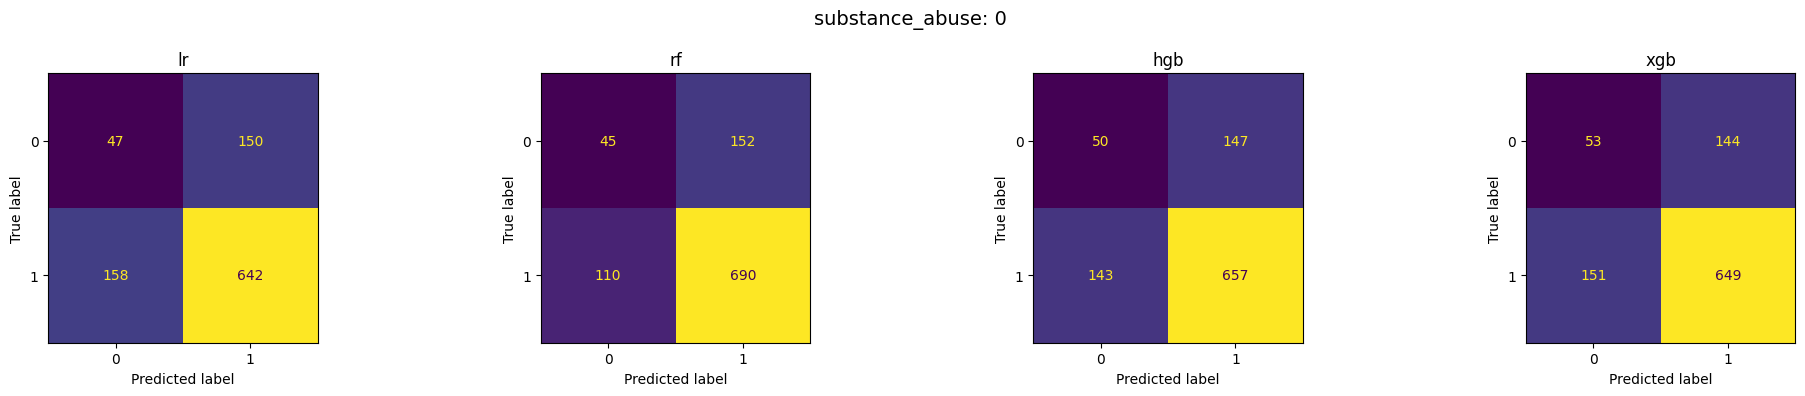

Saved confusion matrices to: /Users/cu20932/Documents/Work/reducehf/output/models/optimisation/subgroup_specific_models/confusion_matrices


In [10]:
CM_DIR = os.path.join(
    OPTIMISATION_DIR,
    "confusion_matrices"
)

os.makedirs(CM_DIR, exist_ok=True)

if IS_DUMMY_DATA:

    for (subgroup_var, subgroup_level), df_group in performance_df.groupby(
        ["subgroup_variable", "subgroup_level"]
    ):

        fig, axes = plt.subplots(
            1,
            len(df_group),
            figsize=(5 * len(df_group), 4)
        )

        if len(df_group) == 1:
            axes = [axes]

        for ax, (_, row) in zip(axes, df_group.iterrows()):

            cm = pd.DataFrame([
                [row["true_negatives"], row["false_positives"]],
                [row["false_negatives"], row["true_positives"]],
            ]).values

            disp = ConfusionMatrixDisplay(
                confusion_matrix=cm,
                display_labels=["0", "1"]
            )

            disp.plot(
                ax=ax,
                colorbar=False
            )

            ax.set_title(row["model"])

        fig.suptitle(
            f"{subgroup_var}: {subgroup_level}",
            fontsize=14
        )

        plt.tight_layout()

        safe_subgroup_var = str(subgroup_var).replace(" ", "_").replace("/", "_")
        safe_subgroup_level = str(subgroup_level).replace(" ", "_").replace("/", "_")

        plot_path = os.path.join(
    CM_DIR,
    f"cm_{OPTIMISATION_METHOD}_{safe_subgroup_var}_{safe_subgroup_level}.png"
)

        fig.savefig(
            plot_path,
            dpi=200,
            bbox_inches="tight"
        )

        plt.show()
        plt.close(fig)

print("Saved confusion matrices to:", CM_DIR)